In [1]:
!pip install ml4eft

In [3]:
!pip install wget

In [4]:
!lhapdf install NNPDF31_lo_as_0118


PDF already installed: NNPDF31_lo_as_0118 (use --upgrade to force install)


In [5]:
import wget
import tarfile
import os
import time
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import rc
import sys
import numpy.core.numeric as numeric
sys.modules["numpy._core.numeric"] = numeric

np.float = float  # patch for deprecated usage

import ml4eft.core.classifier as classifier
import ml4eft.analyse.analyse as analyse
from ml4eft.analyse.animate import Animate
import ml4eft.plotting.features as features
import ml4eft.preproc.constants as constants

import types
sys.modules['pymultinest'] = types.ModuleType('pymultinest')
import ml4eft.limits.optimize_ns as optimize

mt = constants.mt

rc('text', usetex=False)
rc('font', **{'family': 'DejaVu Sans', 'size': 22})

LHAPDF 6.5.4 loading /depot/cms/purdue-af/lhapdf/share/LHAPDF/NNPDF31_lo_as_0118/NNPDF31_lo_as_0118_0000.dat
NNPDF31_lo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 315000


In [6]:
def file_downloader(url, download_dir='./downloads'):
    if not os.path.exists(download_dir):
        os.mkdir(download_dir)
    file = wget.download(url, out=download_dir)
    return file

def untar(path_to_tar, destination='./downloads'):
    with tarfile.open(path_to_tar) as f:
        f.extractall(destination)

download_dir = './downloads'

In [6]:
training_data_url = 'https://dl.dropboxusercontent.com/s/z16fz2ggbn244pl/training_data.tar.gz?dl=0'
training_data = file_downloader(training_data_url);
data_train_loc = training_data.split('.tar')[0]

untar(training_data);

# Load in the EFT Events

coeff = ['ctGRe', 'ctj8']
events_eft = []

for c in coeff:
    path_to_events = os.path.join(data_train_loc, 'tt_{}_{}/events_0.pkl.gz'.format(c, c))
    events, xsec = analyse.Analyse.load_events(path_to_events)
    events_eft.append(events)

# Load in the SM events

events_sm, xsec_sm = analyse.Analyse.load_events(os.path.join(download_dir, 'training_data/tt_sm/events_0.pkl.gz'))

obs_features = list(events_sm.columns.values)


In [224]:
df_sm = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/ttparton_sm/events_0.pkl.gz")
df_ctgre = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/ttparton_ctGRe_ctGRe/events_0.pkl.gz")
df_ctu8 = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/ttparton_ctu8_ctu8/events_0.pkl.gz")
df_ctgre_ctu8 = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/ttparton_ctGRe_ctu8/events_0.pkl.gz")

df_sm = df_sm.iloc[1:, :]
df_ctgre = df_ctgre.iloc[1:,:]
df_ctu8 = df_ctu8.iloc[1:,:]
df_ctgre_ctu8 = df_ctgre_ctu8.iloc[1:,:]

df_ctu8

FileNotFoundError: [Errno 2] No such file or directory: '/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/ttparton_sm/events_0.pkl.gz'

In [48]:
df_ctgre

,gen_ttbar_mass,gen_ll_cHel,gen_c_nn,gen_llbar_delta_phi,gen_b1k,gen_b2k,gen_c_kk,gen_c_rr,gen_top_rapidity,gen_tbar_rapidity,gen_ttbar_rapidity,gen_llbar_pt,gen_l_eta
1,442.374634,0.970207,-0.930459,1.345888,0.128037,-0.336720,-0.043113,0.003365,0.273562,0.543953,0.408724,62.776943,0.618259
2,444.332275,-0.860478,0.224994,3.004191,-0.556389,-0.279282,0.155389,0.480095,-0.627903,0.107163,-0.271568,14.415751,1.398795
3,478.268127,0.375732,0.017614,1.774763,-0.444550,0.912924,-0.405840,0.012494,1.868512,0.471982,1.154180,77.879829,0.193768
4,427.842529,0.407400,0.264919,2.973230,0.390255,-0.147309,-0.057488,-0.614831,0.737143,0.532306,0.640729,5.926910,1.568750
5,2382.286865,0.578748,-0.267129,2.873158,0.025364,-0.804965,-0.020417,-0.291202,-1.211365,-0.046079,-0.622628,477.165283,0.249122
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,476.018829,0.262070,-0.108472,2.530350,0.647740,0.361409,0.234099,-0.387697,0.333842,-0.276362,0.036645,40.719070,-0.057095
14999996,374.131287,-0.255700,0.416543,2.997043,0.572608,-0.236269,-0.135289,-0.025554,-0.697926,-1.198881,-0.942430,33.072235,-1.018259
14999997,453.912537,-0.635815,0.583589,2.628755,0.069590,0.768468,0.053477,-0.001252,1.213467,1.967848,1.530161,42.299561,2.410652
14999998,375.670715,0.514143,-0.241970,1.178514,-0.906548,0.401142,-0.363654,0.091482,-1.942829,-1.158316,-1.557320,63.005184,-0.645940


In [ ]:
feature_dict = {
'gen_top_pt': r'$p_T(t)$',
'gen_top_phi': r'$\phi(t)$',
'gen_top_rapidity': r'$y(t)$',
'gen_top_eta': r'$\eta(t)$',
'gen_top_mass': r'$m(t)$',

'gen_tbar_pt': r'$p_T(\bar{t})$',
'gen_tbar_phi': r'$\phi(\bar{t})$',
'gen_tbar_rapidity': r'$y(\bar{t})$',
'gen_tbar_eta': r'$\eta(\bar{t})$',
'gen_tbar_mass': r'$m(\bar{t})$',

'gen_l_pt': r'$p_T(\ell)$',
'gen_l_eta': r'$\eta(\ell)$',
'gen_l_phi': r'$\phi(\ell)$',
'gen_l_mass': r'$m(\ell)$',
'gen_l_pdgid': r'$\mathrm{PDG}(\ell)$',

'gen_final_l_pt': r'$p_T(\ell_\mathrm{final})$',
'gen_final_l_eta': r'$\eta(\ell_\mathrm{final})$',
'gen_final_l_phi': r'$\phi(\ell_\mathrm{final})$',
'gen_final_l_mass': r'$m(\ell_\mathrm{final})$',
'gen_final_l_pdgid': r'$\mathrm{PDG}(\ell_\mathrm{final})$',

'gen_lbar_pt': r'$p_T(\bar{\ell})$',
'gen_lbar_eta': r'$\eta(\bar{\ell})$',
'gen_lbar_phi': r'$\phi(\bar{\ell})$',
'gen_lbar_mass': r'$m(\bar{\ell})$',
'gen_lbar_pdgid': r'$\mathrm{PDG}(\bar{\ell})$',

'gen_final_lbar_pt': r'$p_T(\bar{\ell}_\mathrm{final})$',
'gen_final_lbar_eta': r'$\eta(\bar{\ell}_\mathrm{final})$',
'gen_final_lbar_phi': r'$\phi(\bar{\ell}_\mathrm{final})$',
'gen_final_lbar_mass': r'$m(\bar{\ell}_\mathrm{final})$',
'gen_final_lbar_pdgid': r'$\mathrm{PDG}(\bar{\ell}_\mathrm{final})$',

'gen_b_pt': r'$p_T(b)$',
'gen_b_eta': r'$\eta(b)$',
'gen_b_phi': r'$\phi(b)$',
'gen_b_mass': r'$m(b)$',

'gen_bbar_pt': r'$p_T(\bar{b})$',
'gen_bbar_eta': r'$\eta(\bar{b})$',
'gen_bbar_phi': r'$\phi(\bar{b})$',
'gen_bbar_mass': r'$m(\bar{b})$',

'gen_nu_pt': r'$p_T(\nu)$',
'gen_nu_eta': r'$\eta(\nu)$',
'gen_nu_phi': r'$\phi(\nu)$',
'gen_nu_mass': r'$m(\nu)$',

'gen_nubar_pt': r'$p_T(\bar{\nu})$',
'gen_nubar_eta': r'$\eta(\bar{\nu})$',
'gen_nubar_phi': r'$\phi(\bar{\nu})$',
'gen_nubar_mass': r'$m(\bar{\nu})$',

'gen_ttbar_pt': r'$p_T(t\bar{t})$',
'gen_ttbar_phi': r'$\phi(t\bar{t})$',
'gen_ttbar_rapidity': r'$y(t\bar{t})$',
'gen_ttbar_eta': r'$\eta(t\bar{t})$',
'gen_ttbar_delta_phi': r'$\Delta\phi(t,\bar{t})$',
'gen_ttbar_delta_eta': r'$\Delta\eta(t,\bar{t})$',
'gen_ttbar_delta_rapidity': r'$\Delta y(t,\bar{t})$',
'gen_ttbar_mass': r'$m(t\bar{t})$',

'gen_llbar_pt': r'$p_T(\ell\bar{\ell})$',
'gen_llbar_phi': r'$\phi(\ell\bar{\ell})$',
'gen_llbar_rapidity': r'$y(\ell\bar{\ell})$',
'gen_llbar_delta_phi': r'$\Delta\phi(\ell,\bar{\ell})$',
'gen_llbar_delta_eta': r'$\Delta\eta(\ell,\bar{\ell})$',
'gen_llbar_delta_rapidity': r'$\Delta y(\ell,\bar{\ell})$',
'gen_llbar_mass': r'$m(\ell\bar{\ell})$',

'gen_MT2': r'$M_{T2}$',
'gen_all_mass': r'$m_\mathrm{all}$',
'gen_r_mass': r'$m_r$',

'gen_jet_multiplicity': r'$N_\mathrm{jets}$',
'gen_x1': r'$x_1$',
'gen_x2': r'$x_2$',
'gen_n_extraJets_iso08': r'$N_\mathrm{extra\,jets}$',

'gen_top_scatteringangle_ttbarframe': r'$\cos\theta^*_{t}$',

'gen_b1k': r'$b_1^k$',
'gen_b2k': r'$b_2^k$',
'gen_b1j': r'$b_1^j$',
'gen_b2j': r'$b_2^j$',
'gen_b1r': r'$b_1^r$',
'gen_b2r': r'$b_2^r$',
'gen_b1q': r'$b_1^q$',
'gen_b2q': r'$b_2^q$',
'gen_b1n': r'$b_1^n$',
'gen_b2n': r'$b_2^n$',

'gen_c_kk': r'$C_{kk}$',
'gen_c_rr': r'$C_{rr}$',
'gen_c_nn': r'$C_{nn}$',
'gen_c_kj': r'$C_{kj}$',
'gen_c_rq': r'$C_{rq}$',
'gen_c_rk': r'$C_{rk}$',
'gen_c_kr': r'$C_{kr}$',
'gen_c_nr': r'$C_{nr}$',
'gen_c_rn': r'$C_{rn}$',
'gen_c_nk': r'$C_{nk}$',
'gen_c_kn': r'$C_{kn}$',
'gen_c_rj': r'$C_{rj}$',
'gen_c_jr': r'$C_{jr}$',

'gen_ll_cHel': r'$C_\mathrm{hel}$',
'gen_ll_cLab': r'$C_\mathrm{lab}$',
'gen_ll_kNorm': r'$k_\mathrm{norm}$',
'gen_ll_rNorm': r'$r_\mathrm{norm}$',

'trueLevelWeight': r'$\mathrm{weight}$'
}



legend_labels = [r'$c_{tG}=10$', r'$\mathrm{SM}$']

In [50]:
sub_features_dict = {
    #'gen_ttbar_pt': r'$p_T^{t\bar{t}}\;[\mathrm{GeV}]$',
    #'gen_ttbar_phi': r'$\phi_{t\bar{t}}$',
    #'gen_ttbar_rapidity': r'$y_{t\bar{t}}$',
    #'gen_ttbar_eta': r'$\eta_{t\bar{t}}$',
    #'gen_ttbar_delta_phi': r'$\Delta\phi(t,\bar{t})$',
    #'gen_ttbar_delta_eta': r'$\Delta\eta(t,\bar{t})$',
    'gen_ttbar_rapidity': r'$\Delta y(t,\bar{t})$',
    'gen_ttbar_mass': r'$m_{t\bar{t}}\;[\mathrm{GeV}]$',
    #'gen_llbar_delta_phi': r'$\Delta\phi(\ell,\bar{\ell})$'
}
legend_labels = [r'$c_{tu8}=2$', r'$c_{tGRe}$',r'$c_{tGRe,tu8}$']

In [51]:
df_eft_list = [df_ctgre,df_ctu8,df_ctgre_ctu8]

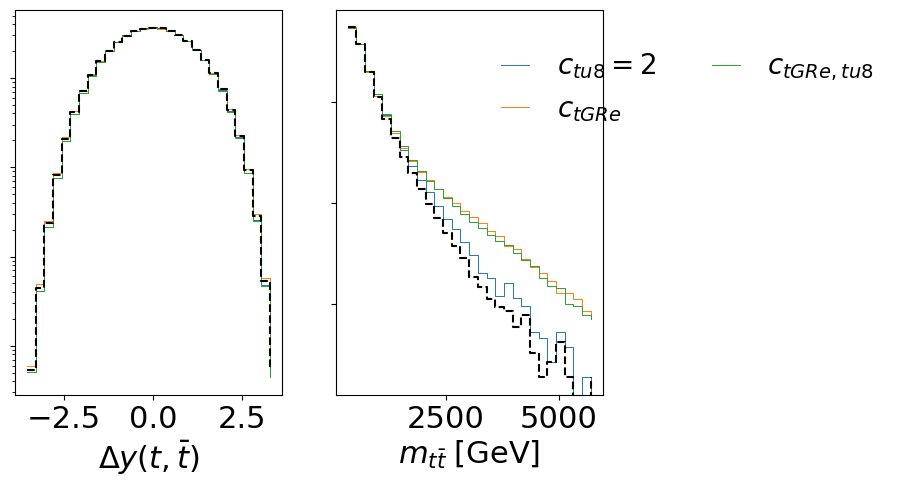

In [52]:
fig = features.plot_features(df_sm, df_eft_list, sub_features_dict, legend_labels);

In [97]:
training_data_url = 'https://dl.dropboxusercontent.com/s/z16fz2ggbn244pl/training_data.tar.gz?dl=0'
training_data = file_downloader(training_data_url);
data_train_loc = training_data.split('.tar')[0]

untar(training_data);

# Load in the EFT Events

coeff = ['ctGRe']
events_eft = []

for c in coeff:
    path_to_events = os.path.join(data_train_loc, 'tt_{}_{}/events_0.pkl.gz'.format(c, c))
    events, xsec = analyse.Analyse.load_events(path_to_events)
    events_eft.append(events)

# Load in the SM events

events_sm, xsec_sm = analyse.Analyse.load_events(os.path.join(download_dir, 'training_data/tt_sm/events_0.pkl.gz'))

obs_features = list(events_sm.columns.values)

events_sm

,sqrts_hat,pt_l1,pt_l2,pt_l_leading,pt_l_trailing,eta_l1,eta_l2,eta_l_leading,eta_l_trailing,pt_ll,m_ll,DeltaPhi_ll,DeltaEta_ll,pt_b_leading,pt_b_trailing,eta_b_leading,eta_b_trailing,pt_bb,m_bb
1,1702.356400,20.532279,308.295118,308.295118,20.532279,-2.065020,-1.378378,-1.378378,-2.065020,288.661066,167.050330,2.854611,0.686642,719.441642,61.252983,-0.595103,-0.297553,674.939606,397.329956
2,1597.155835,321.296675,93.732180,321.296675,93.732180,2.395675,-0.667281,2.395675,-0.667281,243.808973,835.572285,2.631851,1.728394,228.819181,36.771409,0.064635,2.310805,202.872663,304.906431
3,1860.212511,42.634066,40.346863,42.634066,40.346863,-1.342324,1.666454,-1.342324,1.666454,61.587173,185.989824,1.469631,-0.324129,236.676532,178.887249,-2.127759,1.122896,61.457333,1085.595391
4,1671.151358,44.365954,68.175665,68.175665,44.365954,-1.760597,1.686737,1.686737,-1.760597,51.301018,314.810493,2.289832,0.073860,219.833441,136.899478,1.415762,-1.433425,91.365016,761.785714
5,1467.940000,148.790522,386.021918,386.021918,148.790522,0.689735,-0.993332,-0.993332,0.689735,238.946708,658.674901,3.022271,-0.303597,92.528392,78.369846,-0.388545,0.147944,39.214238,172.644465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,1569.717169,105.491453,215.354621,215.354621,105.491453,1.638092,-0.392135,-0.392135,1.638092,114.986825,469.344045,2.915923,1.245957,160.908767,50.601298,0.043227,0.524358,117.914163,180.981245
99997,1644.498574,38.643304,204.035995,204.035995,38.643304,0.507470,-1.391929,-1.391929,0.507470,185.001844,250.524232,2.170360,-0.884459,260.745097,143.029550,1.227220,-1.177890,179.188087,687.684884
99998,2045.033022,152.320608,177.281070,177.281070,152.320608,-0.246921,0.587674,0.587674,-0.246921,119.945338,337.901110,2.411552,-0.340753,360.362755,145.677331,-0.768837,0.257552,289.274374,482.420600
99999,1763.820943,105.010343,424.436796,424.436796,105.010343,1.104649,-0.186152,-0.186152,1.104649,436.408355,418.359318,1.578891,0.918498,380.500925,302.336989,0.654496,-0.008499,682.650395,229.570577


In [53]:
os.path.join(download_dir, 'training_data/tt_sm/events_0.pkl.gz')

'./downloads/training_data/tt_sm/events_0.pkl.gz'

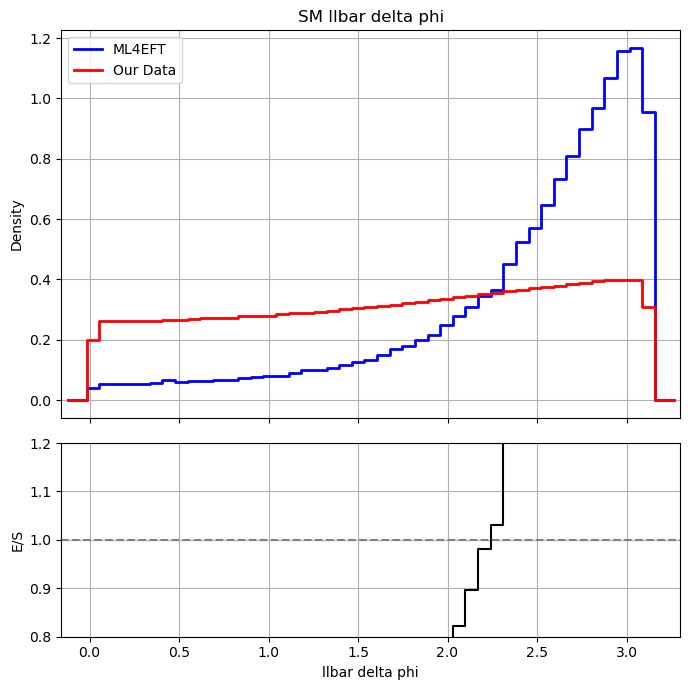

In [17]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 10})

eft_vals = events_sm['DeltaPhi_ll'].dropna()
sm_vals = df_sm['gen_llbar_delta_phi'].dropna()


buffer = 0.05 * (max(eft_vals.max(), sm_vals.max()) - min(eft_vals.min(), sm_vals.min()))
x_min = min(eft_vals.min(), sm_vals.min()) - buffer
x_max = max(eft_vals.max(), sm_vals.max()) + buffer
bins = np.linspace(x_min, x_max, 50)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
hist_eft, _ = np.histogram(eft_vals, bins=bins, density=True)
hist_sm, _ = np.histogram(sm_vals, bins=bins, density=True)

# Ratio with NaN for undefined bins
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(hist_sm > 0, hist_eft / hist_sm, np.nan)

# Plotting
fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax_main.step(bin_centers, hist_eft, where='mid', label="ML4EFT", color='blue', linewidth=2)
ax_main.step(bin_centers, hist_sm, where='mid', label="Our Data", color='red', linewidth=2)
ax_main.set_ylabel("Density")
ax_main.set_title('SM llbar delta phi')
ax_main.legend()
ax_main.grid(True)

ax_main.set_xlim(x_min, x_max)

# Ratio plot
ax_ratio.step(bin_centers, ratio, where='mid', color='black')
ax_ratio.axhline(1.0, linestyle="--", color="gray")
ax_ratio.set_ylabel("E/S")
ax_ratio.set_xlabel('llbar delta phi')
ax_ratio.set_ylim(0.8, 1.2)
ax_ratio.grid(True)

ax_ratio.set_xlim(x_min, x_max)

plt.subplots_adjust(hspace=0.1)
plt.tight_layout()
plt.show()


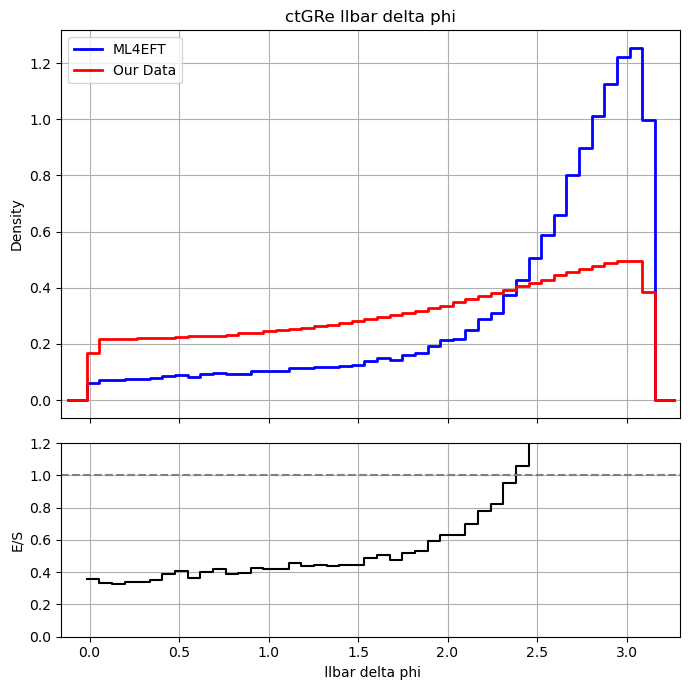

In [18]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 10})

eft_vals = events_eft[0]['DeltaPhi_ll'].dropna()
sm_vals = list_df_eft[0]['gen_llbar_delta_phi'].dropna()


buffer = 0.05 * (max(eft_vals.max(), sm_vals.max()) - min(eft_vals.min(), sm_vals.min()))
x_min = min(eft_vals.min(), sm_vals.min()) - buffer
x_max = max(eft_vals.max(), sm_vals.max()) + buffer
bins = np.linspace(x_min, x_max, 50)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
hist_eft, _ = np.histogram(eft_vals, bins=bins, density=True)
hist_sm, _ = np.histogram(sm_vals, bins=bins, density=True)

# Ratio with NaN for undefined bins
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(hist_sm > 0, hist_eft / hist_sm, np.nan)

# Plotting
fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax_main.step(bin_centers, hist_eft, where='mid', label="ML4EFT", color='blue', linewidth=2)
ax_main.step(bin_centers, hist_sm, where='mid', label="Our Data", color='red', linewidth=2)
ax_main.set_ylabel("Density")
ax_main.set_title('ctGRe llbar delta phi')
ax_main.legend()
ax_main.grid(True)

ax_main.set_xlim(x_min, x_max)

# Ratio plot
ax_ratio.step(bin_centers, ratio, where='mid', color='black')
ax_ratio.axhline(1.0, linestyle="--", color="gray")
ax_ratio.set_ylabel("E/S")
ax_ratio.set_xlabel(' llbar delta phi')
ax_ratio.set_ylim(0., 1.2)
ax_ratio.grid(True)

ax_ratio.set_xlim(x_min, x_max)

plt.subplots_adjust(hspace=0.1)
plt.tight_layout()
plt.show()


In [54]:
path_to_runcard = 'https://dl.dropboxusercontent.com/s/v4ulo6icveh63fw/run_card_tt_llvlvlbb.json?dl=0'
runcard = file_downloader(path_to_runcard)


In [55]:
ML_features = [
#'gen_ttbar_pt',
#'gen_ttbar_phi',
'gen_ttbar_rapidity',
#'gen_ttbar_eta',
#'gen_ttbar_delta_phi',
#'gen_ttbar_delta_eta',
#'gen_ttbar_delta_rapidity',
'gen_ttbar_mass',
#'gen_llbar_pt',
#'gen_l_eta',
]

In [56]:
def new_loss_fn(self, outputs, labels, w_e):
    import torch

    eps = 1e-7
    outputs = torch.clamp(outputs, eps, 1 - eps)

    if self.loss_type == 'CE':

        loss = - (1 - labels) * w_e * torch.log(1 - outputs) \
               - labels * w_e * torch.log(outputs)

    elif self.loss_type == 'QC':

        loss = (1 - labels) * w_e * outputs ** 2 \
             + labels * w_e * (1 - outputs) ** 2

    return torch.sum(loss) / torch.sum(w_e)

classifier.Fitter.loss_fn = new_loss_fn

In [68]:
import json 

with open(runcard) as json_runcard:
    json_runcard_loaded = json.load(json_runcard)
    
json_runcard_loaded['features'] = ML_features
json_runcard_loaded['event_data'] = '/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles'
json_runcard_loaded['c_train'] = {'ctGRe': 2,'ctu8': 2, 'ctGRe_ctu8': 2}
json_runcard_loaded['epochs'] = 30
json_runcard_loaded['lr'] = 0.01
json_runcard_loaded['n_batches'] = 10  # Original: 50
json_runcard_loaded['patience'] = 15
json_runcard_loaded['n_dat'] = 1000000 # Original: 100000
json_runcard_loaded

{'process_id': 'tt',
 'epochs': 30,
 'lr': 0.01,
 'n_batches': 10,
 'output_size': 1,
 'hidden_sizes': [100, 100, 100],
 'n_dat': 1000000,
 'event_data': '/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles',
 'features': ['gen_ttbar_rapidity', 'gen_ttbar_mass'],
 'loss_type': 'CE',
 'scaler_type': 'robust',
 'patience': 15,
 'val_ratio': 0.2,
 'c_train': {'ctGRe': 2, 'ctu8': 2, 'ctGRe_ctu8': 2}}

In [69]:
with open(runcard, 'w') as runcard_updated:
    json.dump(json_runcard_loaded, runcard_updated)

In [70]:
output_dir = './model/quad_limit_ctGRe_ctu8_mtt_y/quad_ctGRe'
c_name = 'ctGRe'

In [72]:
fitter = classifier.Fitter(json_path = runcard,
                           mc_run = 0,
                           c_name = c_name,
                           output_dir = output_dir,
                           print_log = True)

2026-04-16 17:58:00,323 [INFO] All directories created, ready to load the data
2026-04-16 17:58:10,818 [INFO] Dataset loaded from /depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_ctGRe/events_0.pkl.gz
2026-04-16 17:58:10,871 [INFO] Dataset loaded from /depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_sm/events_0.pkl.gz
2026-04-16 17:59:12,801 [INFO] Epoch 1, Training loss 14.615242838859558, Validation loss 17.479227423667908, Overfit counter = 0
2026-04-16 18:00:13,488 [INFO] Epoch 2, Training loss 13.896106123924255, Validation loss 13.891783714294434, Overfit counter = 0
2026-04-16 18:01:12,734 [INFO] Epoch 3, Training loss 13.873488426208496, Validation loss 13.88268268108368, Overfit counter = 0
2026-04-16 18:02:10,300 [INFO] Epoch 4, Training loss 13.862893223762512, Validation loss 13.868831872940063, Overfit counter = 0
2026-04-16 18:03:09,932 [INFO] Epoch 5, Training loss 13.859517455101013, Validation loss 13.85733234882354

In [80]:
path_to_models_root = os.path.join('./model/quad_limit_ctGRe_ctu8_mtt_y/quad_ctGRe', time.strftime("2026/04/16"))
order = 'quad'

models_paths_dict = analyse.Analyse.build_path_dict(root=path_to_models_root,
                        order=order,
                        prefix='model')

analyser = analyse.Analyse(models_paths_dict, order, all=True)
analyser

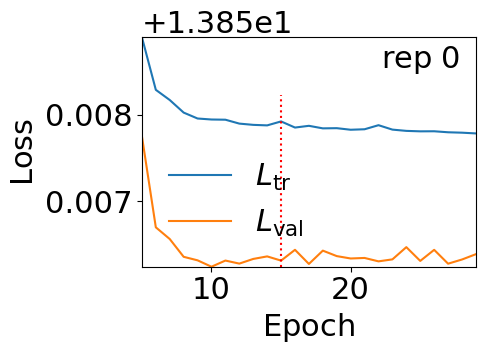

In [79]:
fig, _ = analyser.plot_loss_overview(c_name, order, xlim=5)

In [87]:
c_dict = {'ctGRe': 2, 'ctu8': 0}

r_nn = analyser.likelihood_ratio_nn(c=c_dict, df=df_sm[:100000])
r_nn

array([[       nan, 1.1170745 , 0.8161012 , ..., 1.0142213 , 0.9562575 ,
        0.85195816]], dtype=float32)

In [89]:
mi  = np.min(r_nn)
mi

nan

UFuncTypeError: Cannot cast ufunc 'divide' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

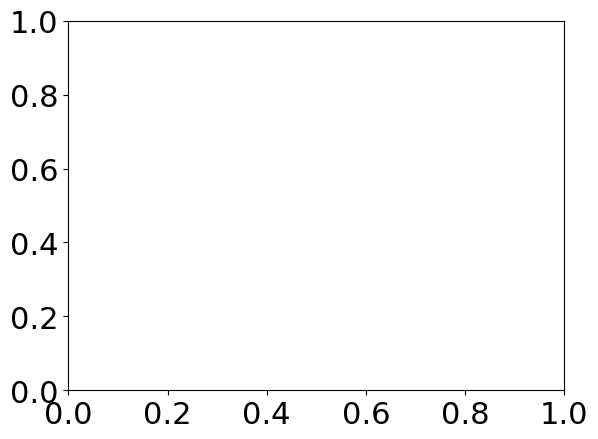

In [25]:
fig, ax = plt.subplots()

analyser.point_by_point_comp_med(df_sm[10000:30000], {'ctGRe': 2, 'ctu8': 0}, ['gen_ttbar_rapidity', 'gen_ttbar_mass'], 'tt', 'lin', ax)
fig 

In [41]:
import math

plt.figure(figsize=(6,5))
plt.rcParams.update({'font.size': 10})

trim_events_sm = []
trim_events_eft = []
r_nn_trimmed = []
i = 0

while i < len(r_nn):
    log_r_nn_temp = abs(math.log(abs(r_nn[i])))
    if log_r_nn_temp > 0.5:
        trim_events_sm.append(events_sm.iloc[i]['pt_l1'])
        trim_events_eft.append(events_eft[0].iloc[i]['pt_l2'])
        r_nn_trimmed.append(r_nn[i])

    i += 1

plt.scatter(trim_events_sm, trim_events_eft, s = 0.5, c = r_nn_trimmed, alpha=1, cmap = 'plasma')

plt.xlabel('pt_l1 [GeV]')
plt.ylabel('pt_l2 [GeV)')
plt.xlim(0,700)
plt.ylim(0,700)
plt.colorbar(label='r(x,x|$\\theta_{0},\\theta_{1}$) $\\theta_{0}$ = SM, $\\theta_{1}$ = ctGRe = 2')
plt.title('Unbinned ML ratio values')
plt.show()

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')


z = r_nn_trimmed
x = trim_events_sm
y = trim_events_eft
c = x + y

ax.scatter(x, y, z, c = z, s = 0.5, cmap = 'plasma')
ax.set_title('3D Unbinned ML ratio values')
ax.set_xlabel('pt_l1 [GeV]')
ax.set_ylabel('pt_l2 [GeV)')
ax.set_zlabel('r(x,x|$\\theta_{0},\\theta_{1}$) $\\theta_{0}$: SM, $\\theta_{1}$: ctGRe = 2')
plt.subplots_adjust(
    left=0.05,
    right=0.85,
    bottom=0.08,
    top=0.92
)
plt.xlim(0,700)
plt.ylim(0,700)
plt.show()

NameError: name 'r_nn' is not defined

<Figure size 600x500 with 0 Axes>

In [81]:
from __future__ import division
from ml4eft.core.truth import tt_prod
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import rc
from scipy.integrate import quad, dblquad
from scipy import integrate
import pylhe

mt = 0.17276
s = 14 ** 2
Gf = 0.000011663787
v = 1 / np.sqrt(Gf * np.sqrt(2)) * 10 ** -3
asQCD = 0.1179
LambdaSMEFT = 1
pb_convert = 3.894E2
yt = 1
try:
    import lhapdf

    p = lhapdf.mkPDF("NNPDF31_lo_as_0118", 0)
except ImportError:
    print("lhapdf not found: exact models will not be available")

class crossSectionSMEFT:
    def sigma_part_gg(self, hats, ctGRe, cut, order):
        if np.sqrt(hats) == 2 * mt:
            return 0

        sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
        kappa_11 = ((v ** 2 * yt ** 2 * asQCD) / (24 * LambdaSMEFT ** 4 * hats ** 3)) * (
                6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
                -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
        kappa_1 = (np.sqrt(np.pi) * v * yt * mt * asQCD) / (6 * LambdaSMEFT ** 2 * hats ** 2 * np.sqrt(2)) * (
                9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
                np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
        sm = (-np.pi * asQCD ** 2) / (12 * hats ** 3) * (
                4 * mt ** 4 * (np.log(1 - sqrt) - np.log(sqrt + 1)) + mt ** 2 * (
                31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt) - 16 * hats * np.log(
            sqrt + 1)) + hats * (7 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 4 * hats * np.log(
            1 - sqrt) - 4 * hats * np.log(sqrt + 1)))

        if order is None:
            return sm
        elif order == 'lin':
            return sm + ctGRe * kappa_1
        elif order == 'quad':
            return sm + ctGRe ** 2 * kappa_11
            
    def sigma_part_qq(self, hats, cuGRe, ctu8, order):
        if np.sqrt(hats)== 2 * mt:
            return 0

        sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
        kappa_11 = sqrt * (8 * np.pi * v ** 2 * yt ** 2 * asQCD * (8 * mt ** 2 + hats)) / (
                108 * np.pi * LambdaSMEFT ** 4 * hats)

        # kappa_22 = (2.0 / 9.0) * sqrt * (hats - mt ** 2) / (48 * np.pi * LambdaSMEFT ** 4)
        # kappa_22 = sqrt * (hats - mt ** 2) / (48 * np.pi * LambdaSMEFT ** 4)
        kappa_22 = (2.0 / 9.0) * (hats * sqrt - mt ** 2 * sqrt) / (12 * 4 * np.pi * LambdaSMEFT ** 4)

        kappa_1 = - (8 * np.sqrt(2 * np.pi) * v * mt * asQCD ** (3 / 2) * sqrt) / (9 * hats * LambdaSMEFT ** 2)
        kappa_2 = asQCD * sqrt * (2 * mt ** 2 + hats) / (27 * hats * LambdaSMEFT ** 2)
        sm = (8 * np.pi * asQCD ** 2 * (2 * mt ** 2 + hats) * sqrt) / (27 * hats ** 2)

        if order is None:
            return sm
        elif order == 'lin':
            return sm + cuGRe * kappa_1 + ctu8 * kappa_2
        elif order == 'quad':
            return sm + cuGRe ** 2 * kappa_11 + ctu8 ** 2 * kappa_22
xsec = crossSectionSMEFT()



def weight(sqrts, mu, x1, x2, c, order):
    ctGRe, cut = c
    hats = sqrts ** 2

    w_e = (xsec.sigma_part_gg(hats, ctGRe, cut, order)) * (p.xfxQ(21, x1, mu) * p.xfxQ(21, x2, mu))

    w_e += (xsec.sigma_part_qq(hats, ctGRe, 0, order)) * (
            p.xfxQ(1, x1, mu) * p.xfxQ(-1, x2, mu) +
            p.xfxQ(1, x2, mu) * p.xfxQ(-1, x1, mu) +
            p.xfxQ(3, x1, mu) * p.xfxQ(-3, x2, mu) +
            p.xfxQ(3, x2, mu) * p.xfxQ(-3, x1, mu) +
            p.xfxQ(5, x1, mu) * p.xfxQ(-5, x2, mu) +
            p.xfxQ(5, x2, mu) * p.xfxQ(-5, x1, mu)
    )

    w_e += (xsec.sigma_part_qq(hats, ctGRe, cut, order)) * (
            p.xfxQ(2, x1, mu) * p.xfxQ(-2, x2, mu) +
            p.xfxQ(2, x2, mu) * p.xfxQ(-2, x1, mu) +
            p.xfxQ(4, x1, mu) * p.xfxQ(-4, x2, mu) +
            p.xfxQ(4, x2, mu) * p.xfxQ(-4, x1, mu)
    )

    return w_e

v_weight = np.vectorize(weight, otypes=[np.float])
v_weight.excluded.add(4)

def new_dsigma_dmtt_dy(y, mtt, c=None, order=None):
    mtt = mtt/1000 # ML4EFT needs the values in TeV but using GeV data
    
    s = 14 ** 2

    if c is None:
        c = np.zeros(2)
    if mtt == 2 * mt: return 0  # if at threshold return zero
    if y < np.log(np.sqrt(s) / (mtt)):  # check whether x = {mtt, y} falls inside the physically allowed region
        x1 = mtt / np.sqrt(s) * np.exp(y)
        x2 = mtt / np.sqrt(s) * np.exp(-y)
        dsigma_dmtt_dy = 2 * mtt / s * v_weight(mtt, 91.188, x1, x2, c, order) / (x1 * x2)
        return pb_convert * dsigma_dmtt_dy
    else:
        return 0

def new_likelihood_ratio_truth(events, c, features, process, order=None):
    n_features = len(features)

    if process == 'tt':
        c = np.array([c['ctGRe'], c['ctu8']])
        if n_features == 1:
            dsigma_0 = [tt_prod.dsigma_dmtt(*x[features], c, order) for _, x in events.iterrows()]  # EFT
            dsigma_1 = [tt_prod.dsigma_dmtt(*x[features]) for _, x in
                        events.iterrows()]  # SM
        elif n_features == 2:
            dsigma_0 = [new_dsigma_dmtt_dy(*x[features], c, order) for _, x in
                        events.iterrows()]  # EFT
            dsigma_1 = [new_dsigma_dmtt_dy(*x[features]) for _, x in
                        events.iterrows()]  # SM
        elif n_features == 3:
            dsigma_0 = [tt_prod.dsigma_dmtt_dy_dpt(*x[features], c, order) for
                        index, x in
                        events.iterrows()]  # EFT
            dsigma_1 = [tt_prod.dsigma_dmtt_dy_dpt(*x[features]) for
                        index, x in
                        events.iterrows()]  # SM

    dsigma_0 = np.array(dsigma_0, dtype = float)
    dsigma_1 = np.array(dsigma_1, dtype = float)

    ratio = np.divide(dsigma_0, dsigma_1, out=np.zeros_like(dsigma_0), where=dsigma_1 != 0)

    return ratio.flatten()

def edited_likelihood_ratio_nn(c, df=None, epoch=-1):

    return analyser.likelihood_ratio_nn(c, df)

def new_point_by_point_comp_med(df, c, features, process, order, ax, text=None):

    r_nn = edited_likelihood_ratio_nn(c, df=df)
    tau_nn = np.log(r_nn)

    r_truth = new_likelihood_ratio_truth(df, c, features, process, order)
    tau_truth = np.log(r_truth)

    fig = plt.figure(figsize=(8, 8))
    x = np.linspace(-0.4, 1.7, 100)

    ax.scatter(tau_truth, np.median(tau_nn, axis=0), s=2, color='red')
    ax.plot(x, x, linestyle='dashed', color='grey')
    ax.set_xlabel(r'$\log r(x, c)^{\rm{Unbinned}\;\rm{exact}}$')
    ax.set_ylabel(r'$\log r(x, c)^{\rm{Unbinned}\;\rm{ML}}$')
    ax.set_xlim((np.min(x), np.max(x)))
    ax.set_ylim((np.min(x), np.max(x)))

    if text is not None:
        ax.text(0.95, 0.1, text,
                horizontalalignment='right',
                verticalalignment='center',
                transform=ax.transAxes)

    fig.tight_layout()

LHAPDF 6.5.4 loading /depot/cms/purdue-af/lhapdf/share/LHAPDF/NNPDF31_lo_as_0118/NNPDF31_lo_as_0118_0000.dat
NNPDF31_lo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 315000


In [82]:
analyser.likelihood_ratio_truth = new_likelihood_ratio_truth
tt_prod.dsigma_dmtt_dy = new_dsigma_dmtt_dy

In [ ]:
features_0 = ['gen_ttbar_rapidity', 'gen_ttbar_mass']
df_sm_cut = df_sm
dsigma_0 = [dsigma_dmtt_dy(*x[features_0], {2,0}, 'lin') for _, x in df_sm_cut.iterrows()]  # EFT
print(dsigma_0)

/tmp/ipykernel_91227/3114396103.py:31: RuntimeWarning: invalid value encountered in sqrt
  sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
/tmp/ipykernel_91227/3114396103.py:33: RuntimeWarning: invalid value encountered in sqrt
  6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
/tmp/ipykernel_91227/3114396103.py:34: RuntimeWarning: invalid value encountered in sqrt
  -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
/tmp/ipykernel_91227/3114396103.py:36: RuntimeWarning: invalid value encountered in sqrt
  9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
/tmp/ipykernel_91227/3114396103.py:37: RuntimeWarning: invalid value encountered in sqrt
  np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
/tmp/ipykernel_91227/3114396103.py:40: RuntimeWarning: invalid value encountered in sqrt
  31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt

In [58]:
edited_likelihood_ratio_nn({'ctGRe': 2, 'ctu8': 0},df_sm[1000000:1010000]);


[[0.9793327  1.020259   0.97951823 ... 1.0386817  0.9581997  0.9748811 ]]


In [55]:
temp = edited_likelihood_ratio_truth(df_sm[1000000:1010000],{'ctGRe': 2, 'ctu8': 0},['gen_ttbar_rapidity', 'gen_ttbar_mass'],'tt','lin')


/tmp/ipykernel_91227/1704014700.py:31: RuntimeWarning: invalid value encountered in sqrt
  sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
/tmp/ipykernel_91227/1704014700.py:33: RuntimeWarning: invalid value encountered in sqrt
  6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
/tmp/ipykernel_91227/1704014700.py:34: RuntimeWarning: invalid value encountered in sqrt
  -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
/tmp/ipykernel_91227/1704014700.py:36: RuntimeWarning: invalid value encountered in sqrt
  9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
/tmp/ipykernel_91227/1704014700.py:37: RuntimeWarning: invalid value encountered in sqrt
  np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
/tmp/ipykernel_91227/1704014700.py:40: RuntimeWarning: invalid value encountered in sqrt
  31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt

<module 'matplotlib.pyplot' from '/depot/cms/kernels/python3/lib/python3.10/site-packages/matplotlib/pyplot.py'>

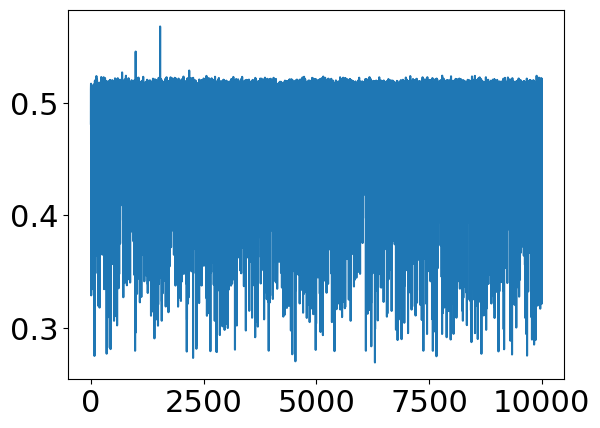

In [29]:
plt.plot(temp)
plt

/tmp/ipykernel_54538/1581725553.py:31: RuntimeWarning: invalid value encountered in sqrt
  sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
/tmp/ipykernel_54538/1581725553.py:33: RuntimeWarning: invalid value encountered in sqrt
  6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
/tmp/ipykernel_54538/1581725553.py:34: RuntimeWarning: invalid value encountered in sqrt
  -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
/tmp/ipykernel_54538/1581725553.py:36: RuntimeWarning: invalid value encountered in sqrt
  9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
/tmp/ipykernel_54538/1581725553.py:37: RuntimeWarning: invalid value encountered in sqrt
  np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
/tmp/ipykernel_54538/1581725553.py:40: RuntimeWarning: invalid value encountered in sqrt
  31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt

ValueError: Axis limits cannot be NaN or Inf

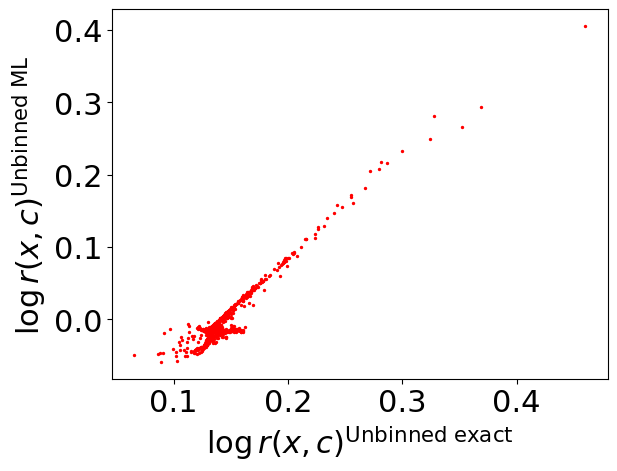

<Figure size 800x800 with 0 Axes>

In [83]:
fig, ax = plt.subplots()

analyser.point_by_point_comp_med(df_sm.sample(n=1000, random_state=2112),
                        {'ctGRe': 2, 'ctu8': 0},
                        ['gen_ttbar_rapidity','gen_ttbar_mass'],
                        'tt', 'quad', ax)

IOStream.flush timed out
/tmp/ipykernel_1100/3318353528.py:15: RuntimeWarning: divide by zero encountered in log
  tau_truth = np.log(r_like_truth[0])
/depot/cms/kernels/python3/lib/python3.10/site-packages/numpy/core/function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start


r_like_nn_trimmed= (1, 100000) 
 r_like_truth= (100000,) 
SM= (100000, 19)


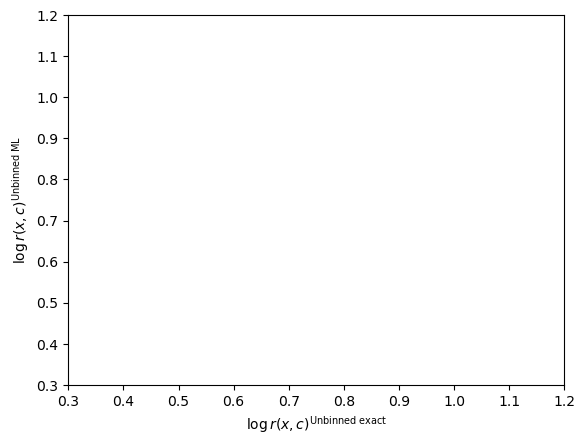

<Figure size 800x800 with 0 Axes>

In [125]:
fig, ax = plt.subplots()

r_like_nn = edited_likelihood_ratio_nn(c=c, df=events_sm)
"""
r_like_nn_trimmed = []
i = 0
while i < len(r_like_nn):
    if r_like_nn[i] > 0:
        r_like_nn_trimmed.append(r_like_nn[i])
    i += 1
"""
tau_nn = np.log(abs(r_like_nn[0]))

r_like_truth = edited_likelihood_ratio_truth(events_sm, c=c, features=['pt_l1', 'pt_l2'], process='tt',)
tau_truth = np.log(r_like_truth[0])

print('r_like_nn_trimmed=',np.shape(r_like_nn),'\n r_like_truth=', np.shape(r_like_truth),'\nSM=', np.shape(events_sm)) 
fig = plt.figure(figsize=(8, 8))
x = np.linspace(np.min(tau_truth) - 0.1, np.max(tau_truth) + 0.1, 100)

ax.scatter(tau_truth, np.median(tau_nn, axis=0), s=2, color='red')
ax.plot(x, x, linestyle='dashed', color='grey')
ax.set_xlabel(r'$\log r(x, c)^{\rm{Unbinned}\;\rm{exact}}$')
ax.set_ylabel(r'$\log r(x, c)^{\rm{Unbinned}\;\rm{ML}}$')
ax.set_xlim((0.3, 1.2))
ax.set_ylim((0.3, 1.2))


fig.tight_layout()

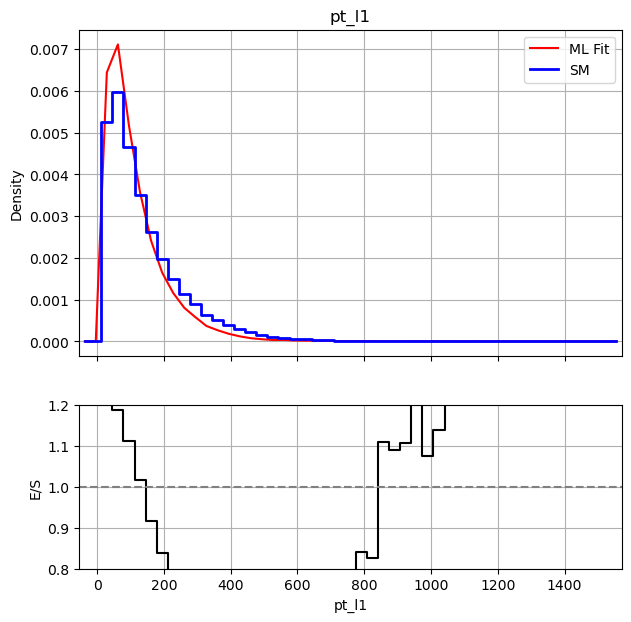

<Figure size 200x200 with 0 Axes>

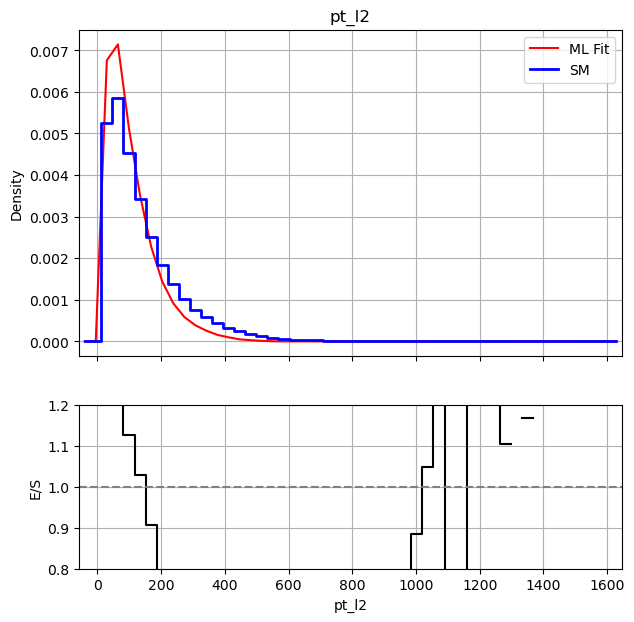

<Figure size 200x200 with 0 Axes>

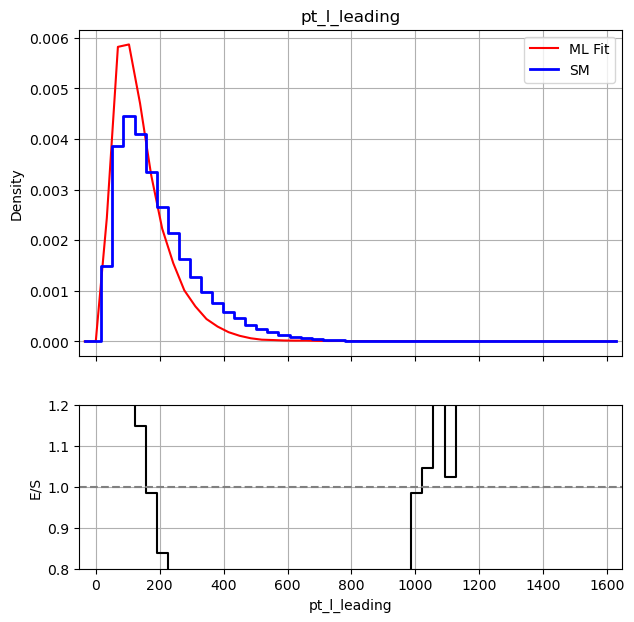

<Figure size 200x200 with 0 Axes>

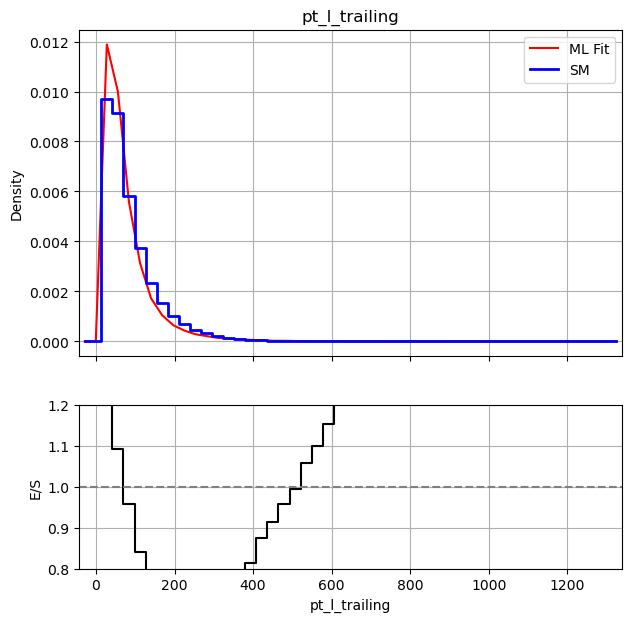

<Figure size 200x200 with 0 Axes>

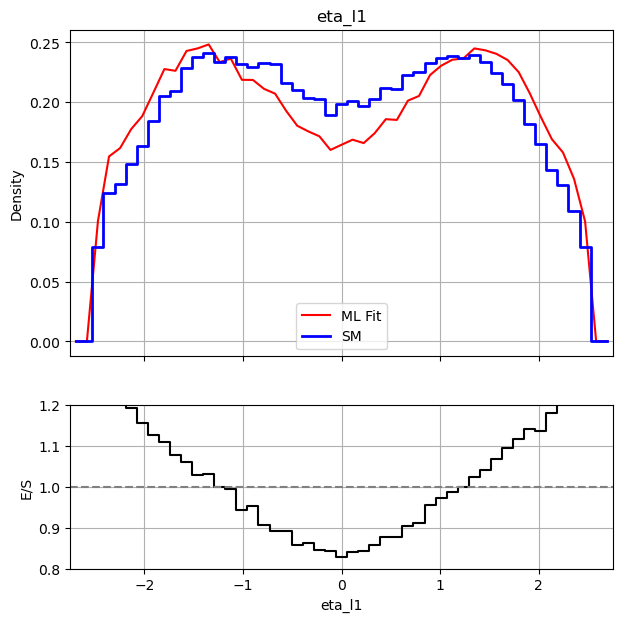

<Figure size 200x200 with 0 Axes>

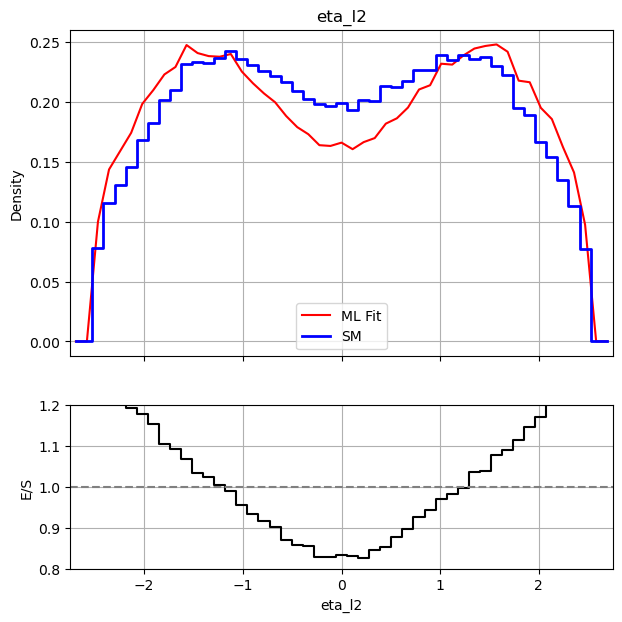

<Figure size 200x200 with 0 Axes>

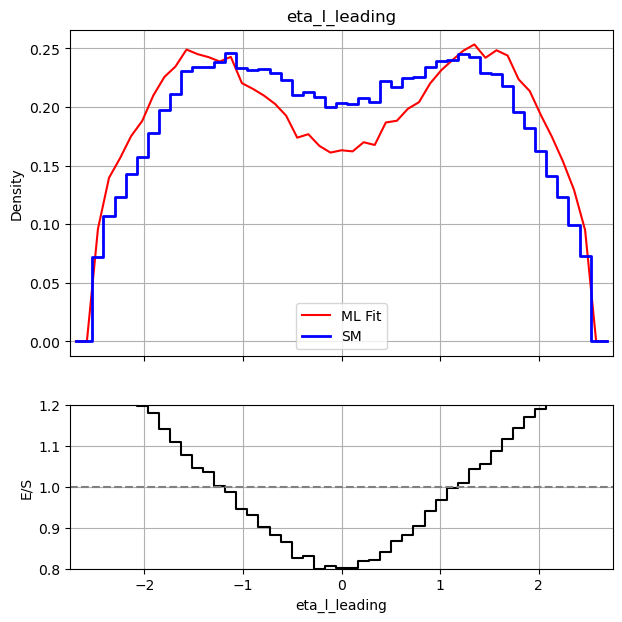

<Figure size 200x200 with 0 Axes>

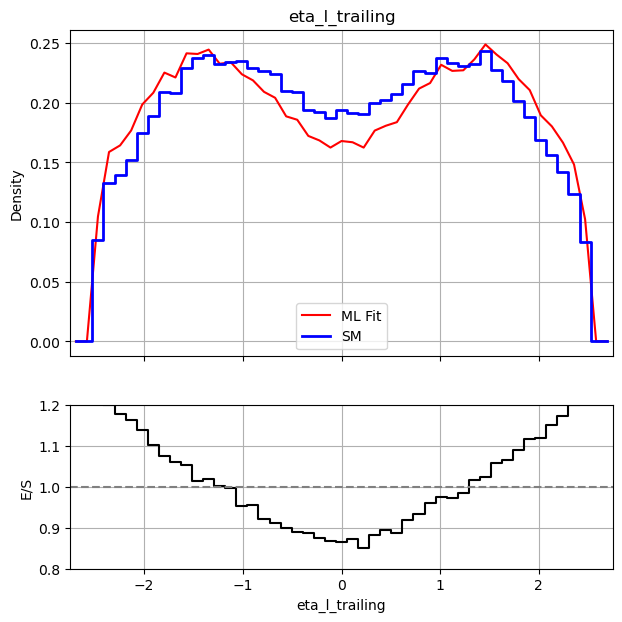

<Figure size 200x200 with 0 Axes>

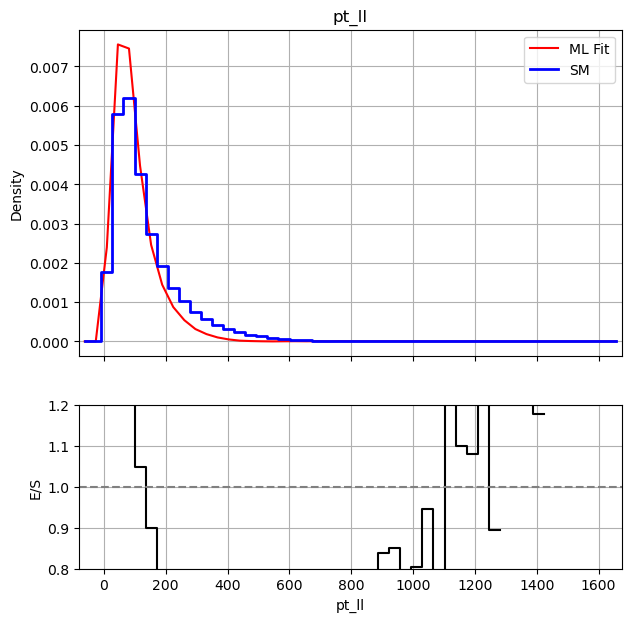

<Figure size 200x200 with 0 Axes>

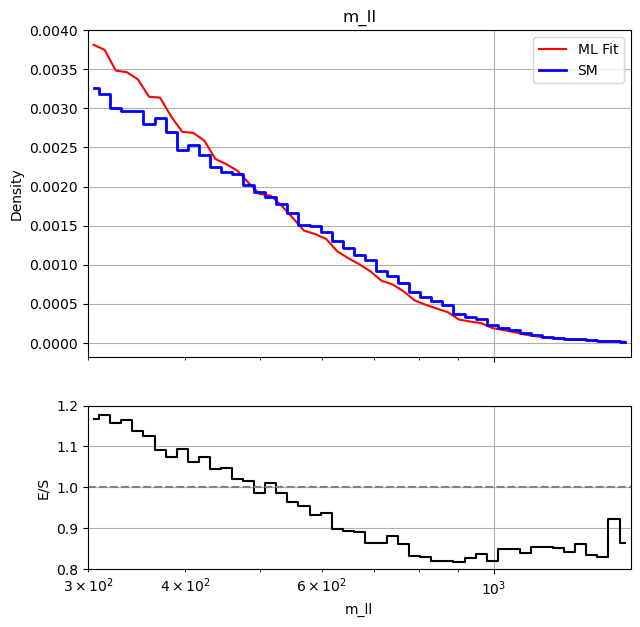

<Figure size 200x200 with 0 Axes>

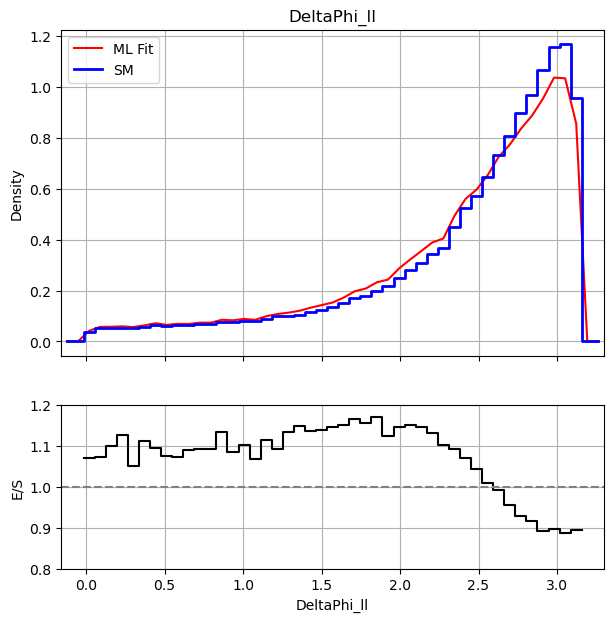

<Figure size 200x200 with 0 Axes>

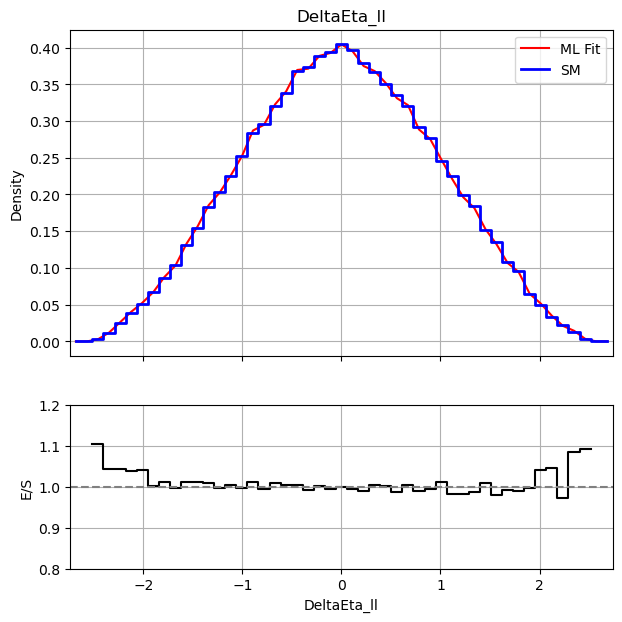

<Figure size 200x200 with 0 Axes>

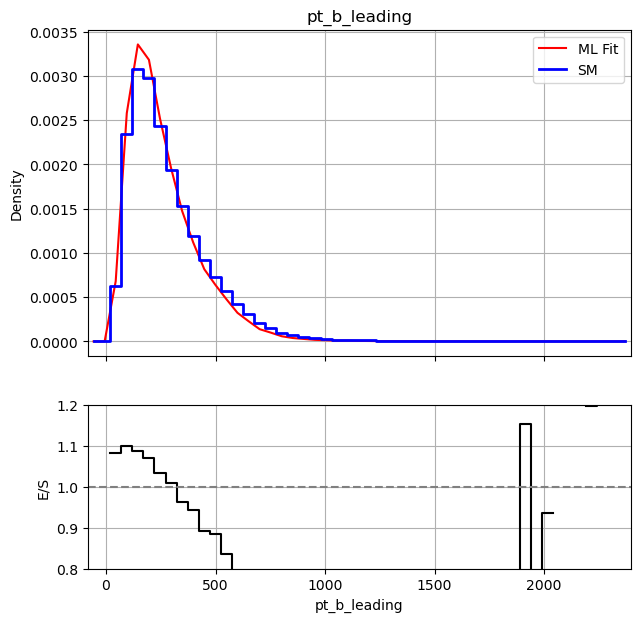

<Figure size 200x200 with 0 Axes>

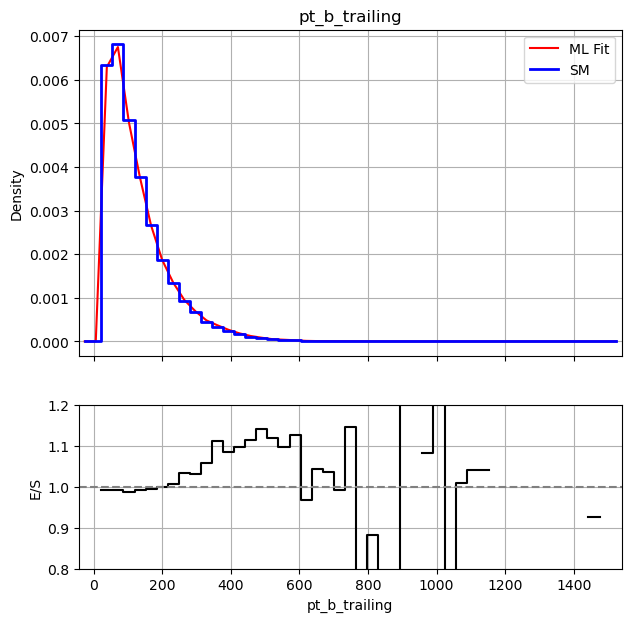

<Figure size 200x200 with 0 Axes>

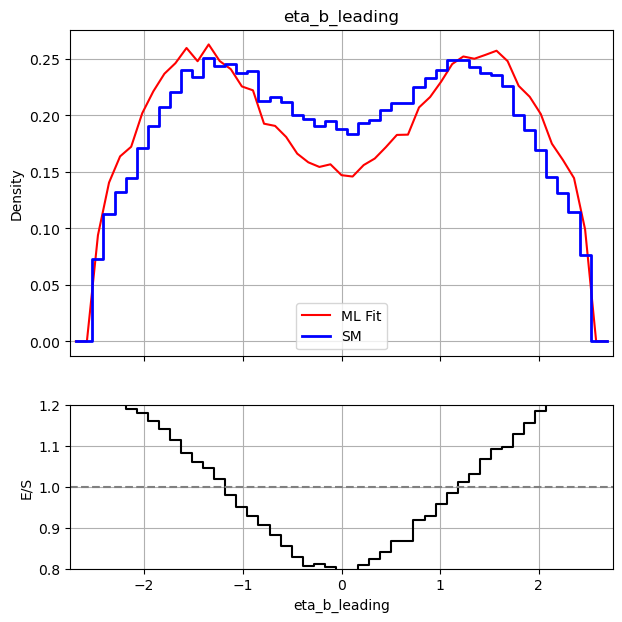

<Figure size 200x200 with 0 Axes>

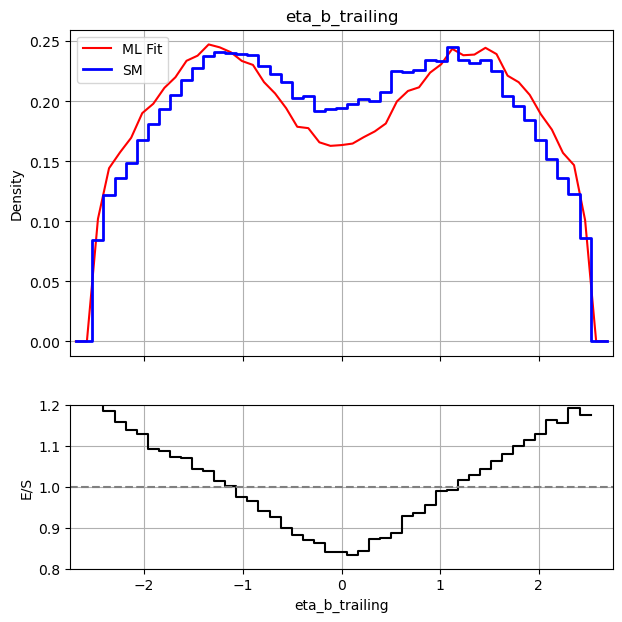

<Figure size 200x200 with 0 Axes>

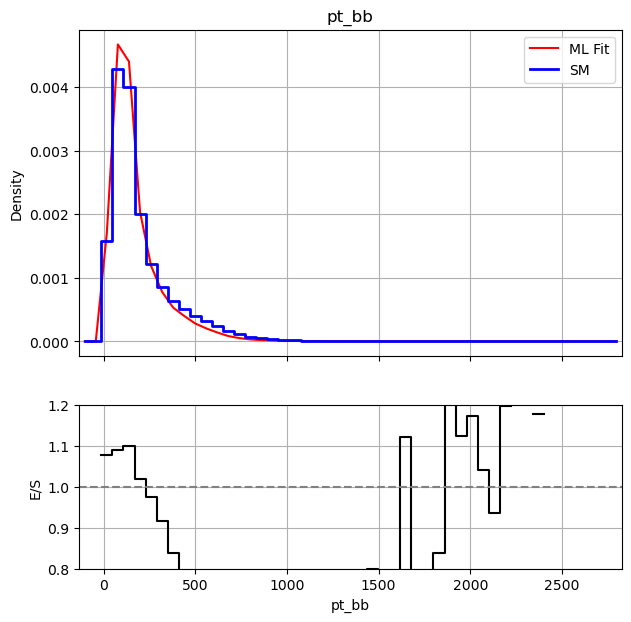

<Figure size 200x200 with 0 Axes>

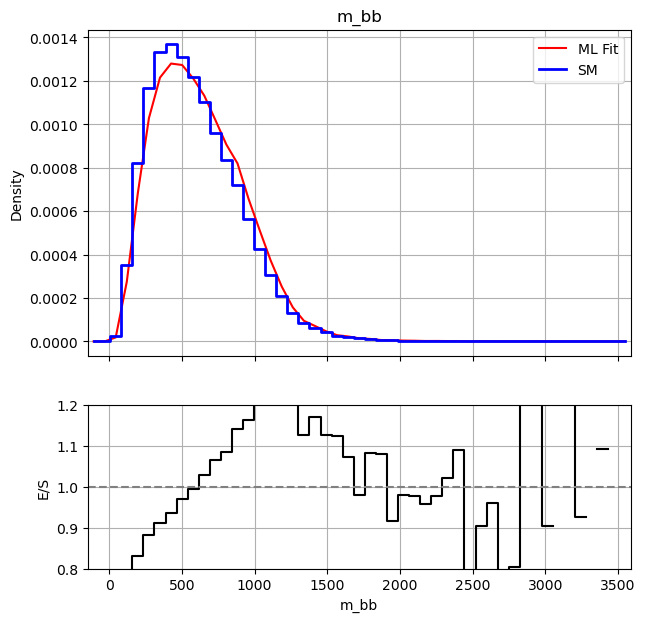

<Figure size 200x200 with 0 Axes>

In [34]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 10})


VARS = obs_features

for var in VARS:
    sm_vals = events_sm[var]
    c_dict = {'ctGRe': 2, 'ctu8': 0}
    r_nn = analyser.likelihood_ratio_nn(c=c_dict, df=events_sm).flatten()
    
    if var == "m_ll":
        x_min, x_max = 300, 1500
        bins = np.logspace(np.log10(x_min), np.log10(x_max), 50)
    else:
        buffer = 0.05 * (max(sm_vals) - min(sm_vals))
        x_min = min(sm_vals) - buffer
        x_max = max(sm_vals) + buffer
        bins = np.linspace(x_min, x_max, 50)
    
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    hist_sm, _ = np.histogram(sm_vals, bins=bins, density=True)
    hist_r, _ = np.histogram(sm_vals, bins=bins, weights=r_nn, density=True)
    
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(hist_sm > 0, hist_r / hist_sm, np.nan)
        
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    
    ax_main.plot(bin_centers, hist_r, color='red', lw=1.5, label='ML Fit')
    ax_main.step(bin_centers, hist_sm, where='mid', label="SM", color='blue', linewidth=2)
    ax_main.set_ylabel("Density")
    ax_main.set_title(var)
    ax_main.legend()
    ax_main.grid(True)
    
    ax_main.set_xlim(x_min, x_max)

    if var == "m_ll":
        ax_main.set_xscale("log")
        ax_main.set_xlim(300, 1500)
    else:
        ax_main.set_xlim(x_min, x_max)
        
    # Ratio plot
    ax_ratio.step(bin_centers, ratio, where='mid', color='black')
    ax_ratio.axhline(1.0, linestyle="--", color="gray")
    ax_ratio.set_ylabel("E/S")
    ax_ratio.set_xlabel(var)
    ax_ratio.set_ylim(0.8, 1.2)
    ax_ratio.grid(True)
    ax_ratio.set_xlim(x_min, x_max)

    if var == "m_ll":
        ax_ratio.set_xscale("log")
        ax_ratio.set_xlim(300, 1500)
    else:
        ax_ratio.set_xlim(x_min, x_max)
    plt.figure(figsize=(2, 2))
    plt.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.show()


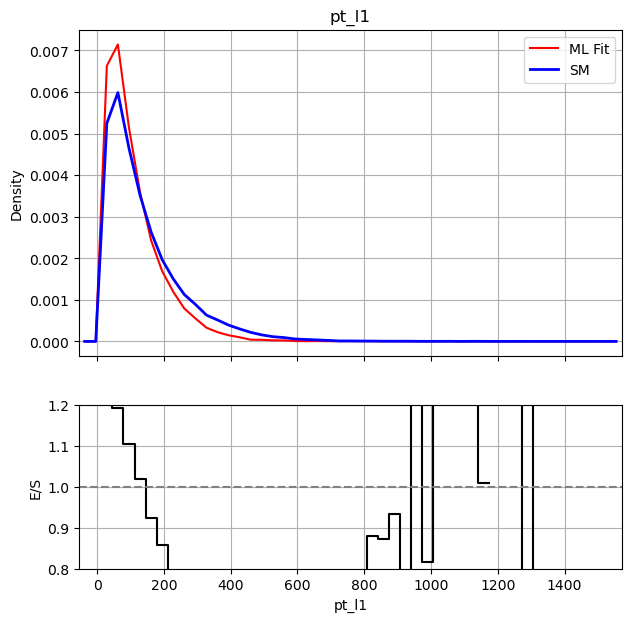

<Figure size 200x200 with 0 Axes>

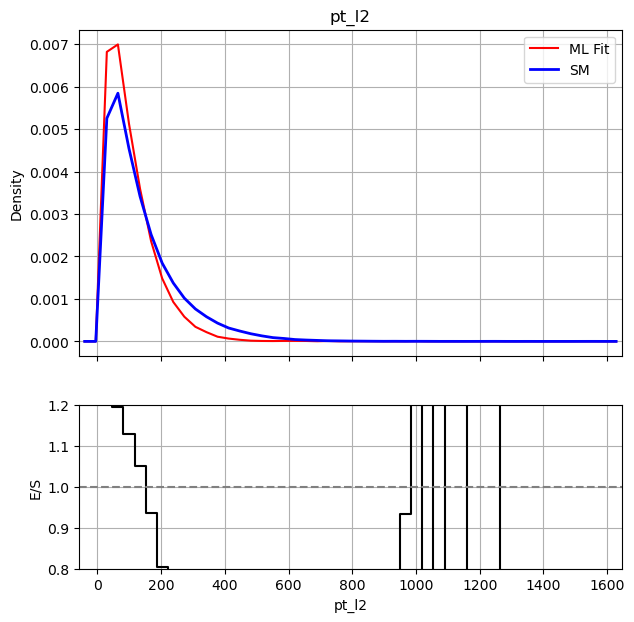

<Figure size 200x200 with 0 Axes>

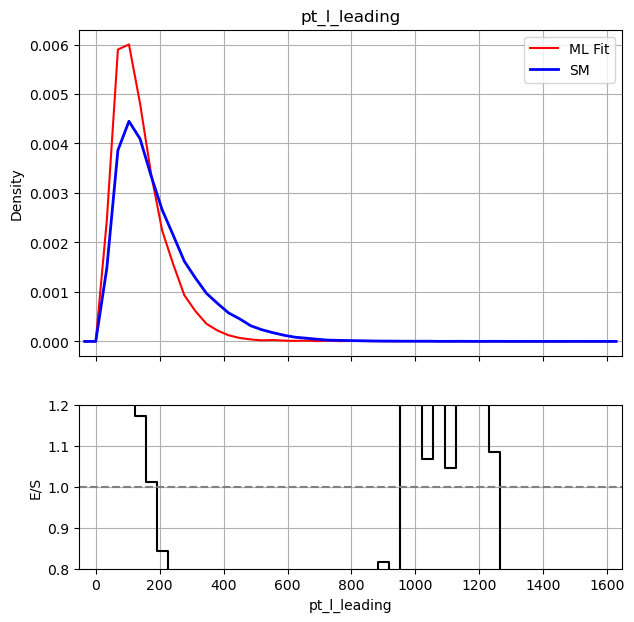

<Figure size 200x200 with 0 Axes>

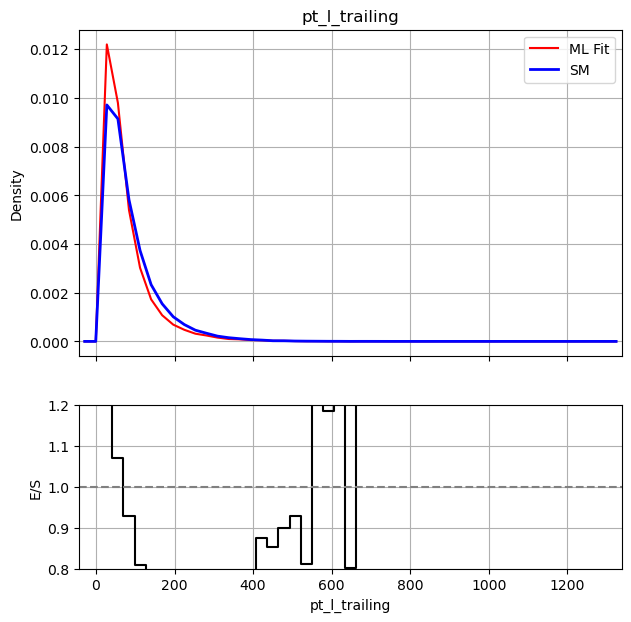

<Figure size 200x200 with 0 Axes>

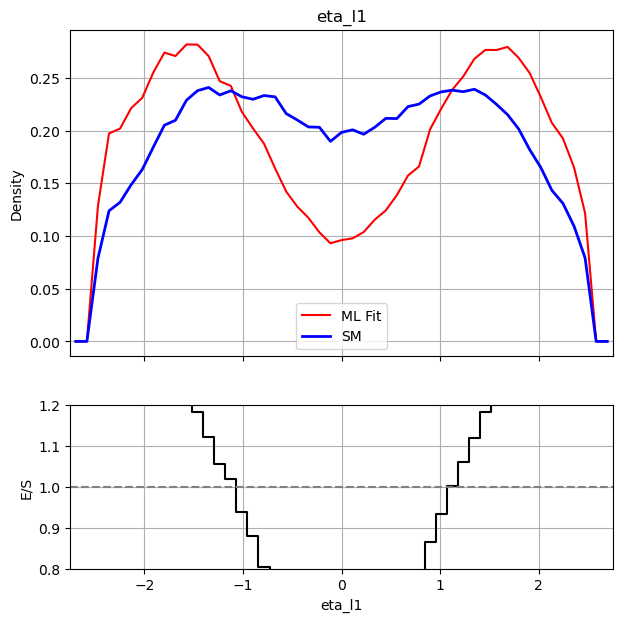

<Figure size 200x200 with 0 Axes>

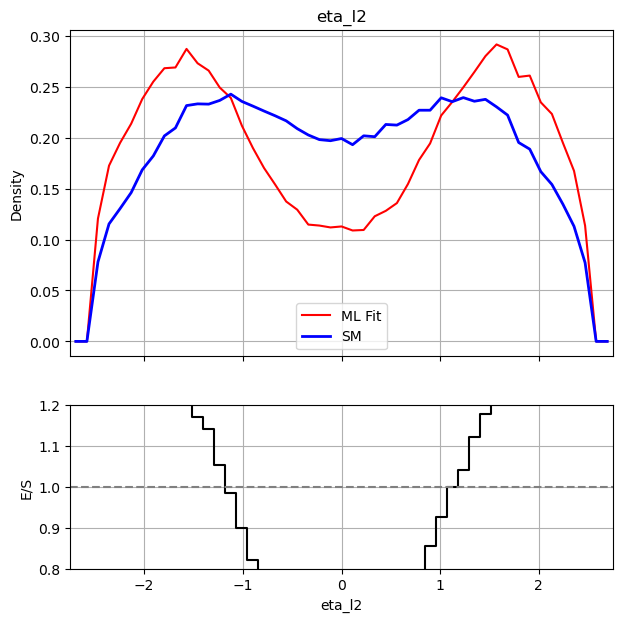

<Figure size 200x200 with 0 Axes>

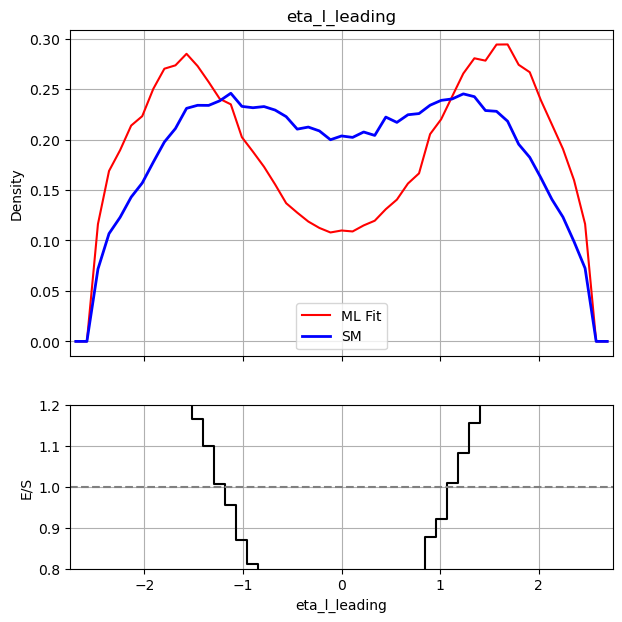

<Figure size 200x200 with 0 Axes>

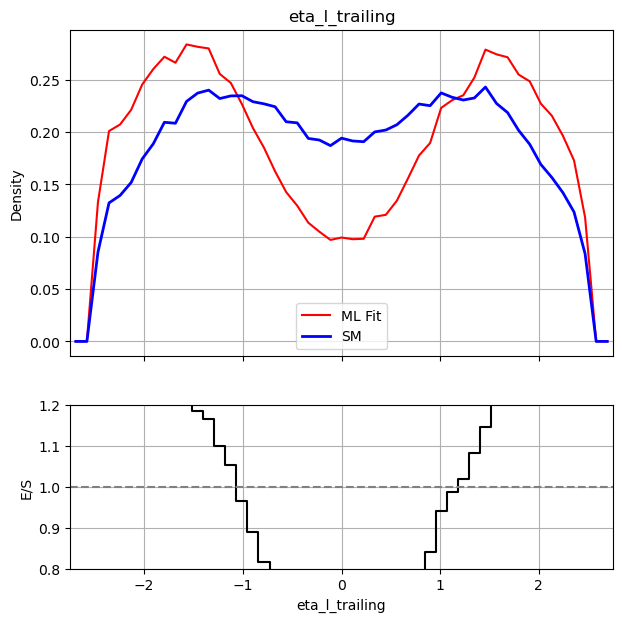

<Figure size 200x200 with 0 Axes>

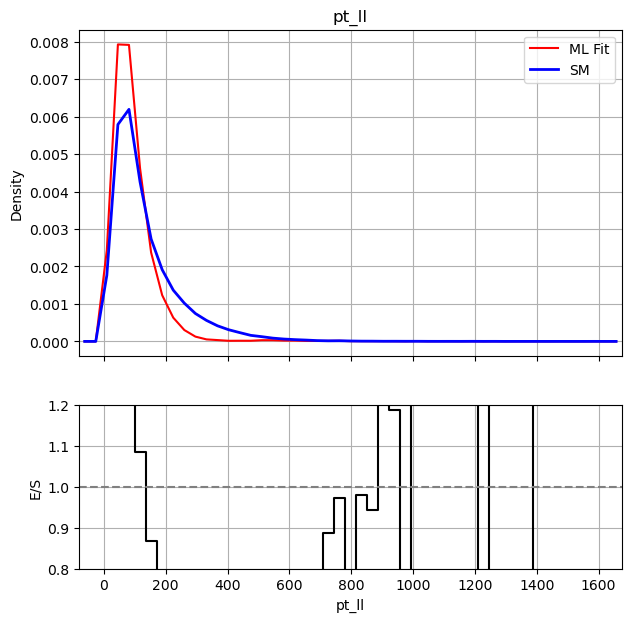

<Figure size 200x200 with 0 Axes>

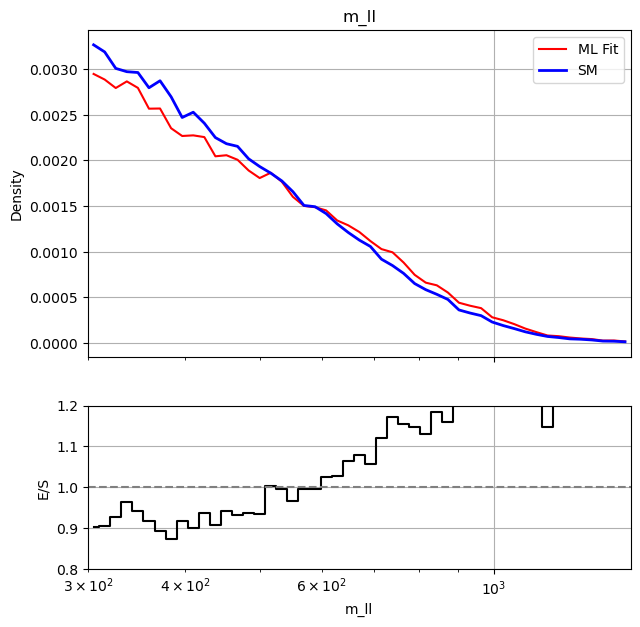

<Figure size 200x200 with 0 Axes>

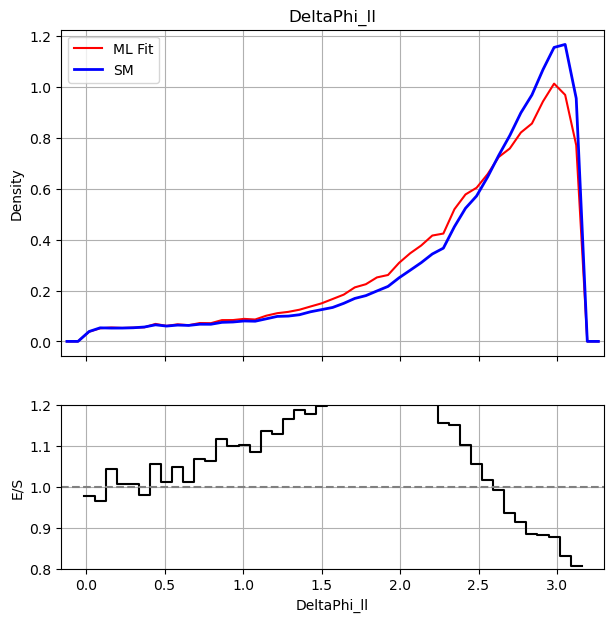

<Figure size 200x200 with 0 Axes>

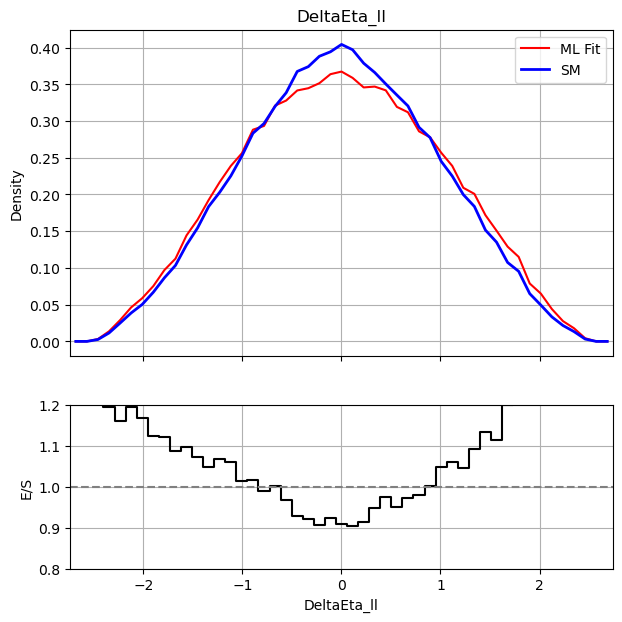

<Figure size 200x200 with 0 Axes>

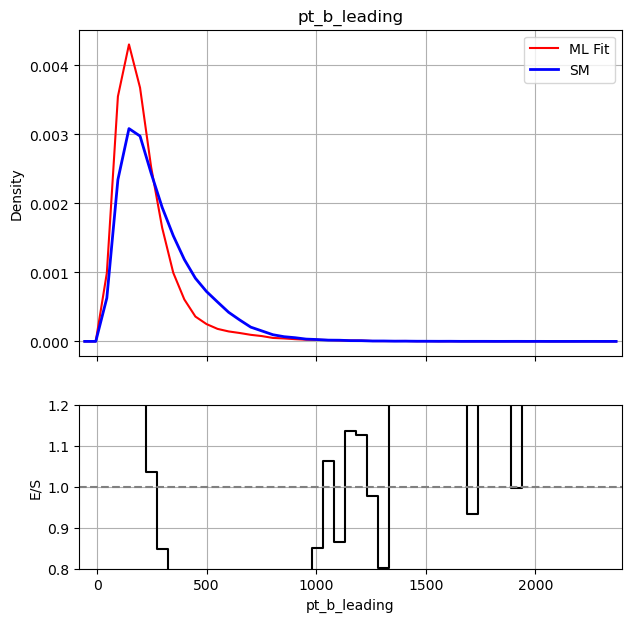

<Figure size 200x200 with 0 Axes>

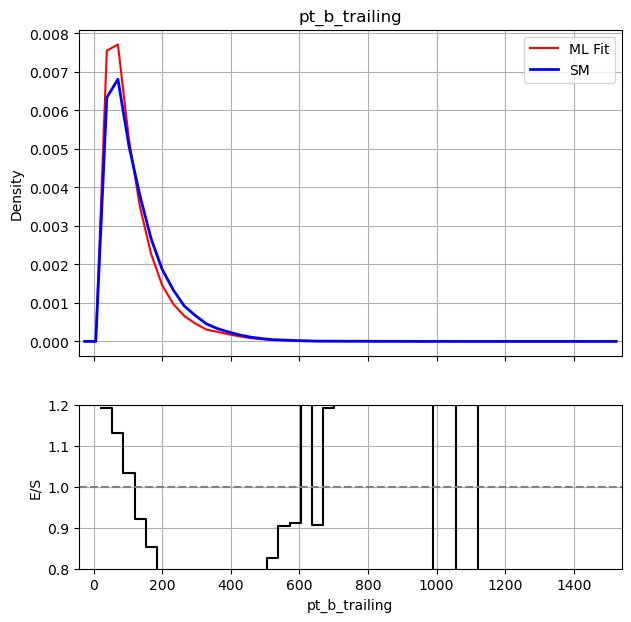

<Figure size 200x200 with 0 Axes>

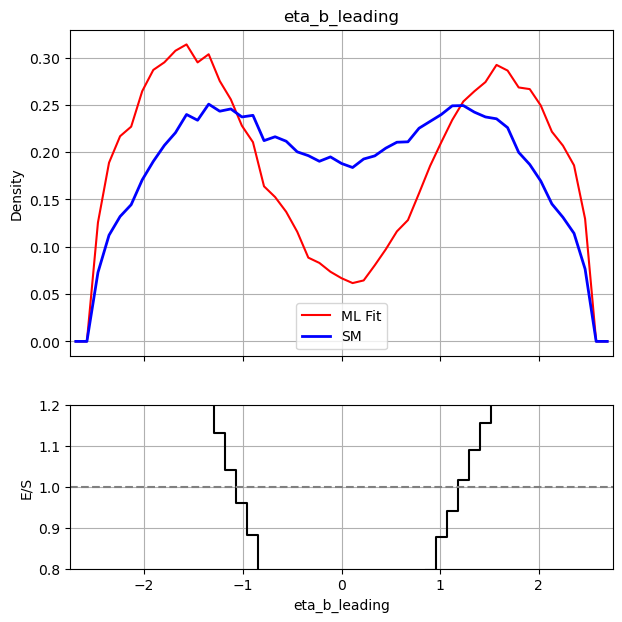

<Figure size 200x200 with 0 Axes>

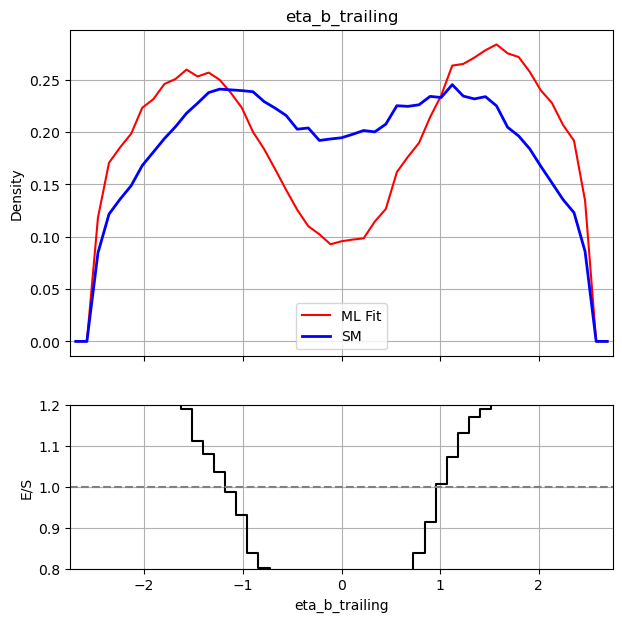

<Figure size 200x200 with 0 Axes>

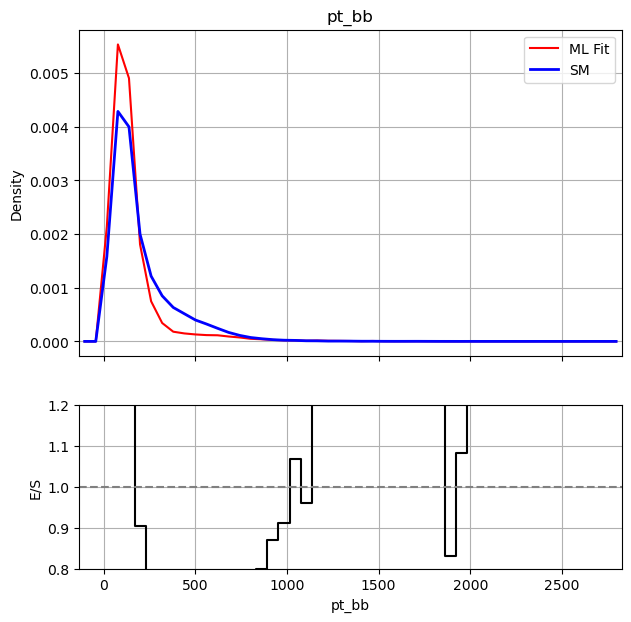

<Figure size 200x200 with 0 Axes>

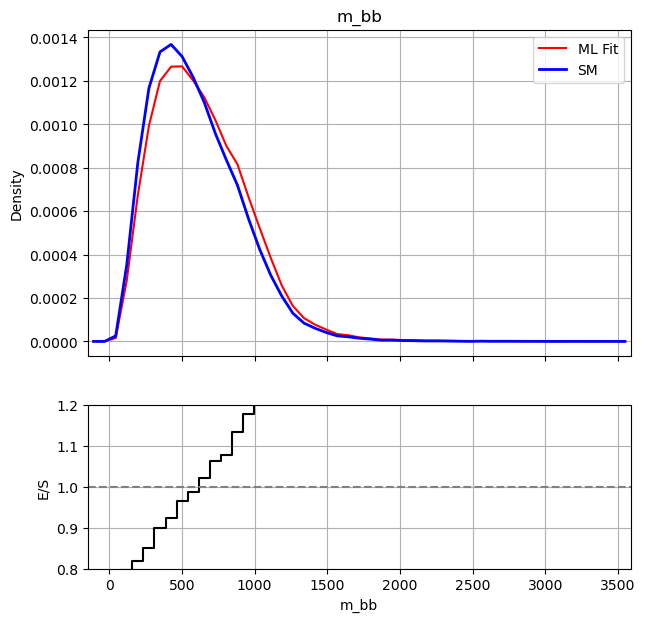

<Figure size 200x200 with 0 Axes>

In [84]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 10})


VARS = obs_features

for var in VARS:
    sm_vals = events_sm[var]
    c_dict = {'ctGRe': 2, 'ctu8': 0}
    r_nn = analyser.likelihood_ratio_nn(c=c_dict, df=events_sm).flatten()
    
    if var == "m_ll":
        x_min, x_max = 300, 1500
        bins = np.logspace(np.log10(x_min), np.log10(x_max), 50)
    else:
        buffer = 0.05 * (max(sm_vals) - min(sm_vals))
        x_min = min(sm_vals) - buffer
        x_max = max(sm_vals) + buffer
        bins = np.linspace(x_min, x_max, 50)
    
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    hist_sm, _ = np.histogram(sm_vals, bins=bins, density=True)
    hist_r, _ = np.histogram(sm_vals, bins=bins, weights=r_nn, density=True)
    
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(hist_sm > 0, hist_r / hist_sm, np.nan)
        
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

    ax_main.plot(bin_centers, hist_r, color='red', lw=1.5, label='ML Fit')
    ax_main.plot(bin_centers, hist_sm, label="SM", color='blue', linewidth=2)
    ax_main.set_ylabel("Density")
    ax_main.set_title(var)
    ax_main.legend()
    ax_main.grid(True)
    
    ax_main.set_xlim(x_min, x_max)

    
    if var == "m_ll":
        ax_main.set_xscale("log")
        ax_main.set_xlim(300, 1500)
    else:
        ax_main.set_xlim(x_min, x_max)
        
    # Ratio plot
    ax_ratio.step(bin_centers, ratio, where='mid', color='black')
    ax_ratio.axhline(1.0, linestyle="--", color="gray")
    ax_ratio.set_ylabel("E/S")
    ax_ratio.set_xlabel(var)
    ax_ratio.set_ylim(0.8, 1.2)
    ax_ratio.grid(True)
    ax_ratio.set_xlim(x_min, x_max)

    if var == "m_ll":
        ax_ratio.set_xscale("log")
        ax_ratio.set_xlim(300, 1500)
    else:
        ax_ratio.set_xlim(x_min, x_max)
    plt.figure(figsize=(2, 2))
    plt.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.show()
    

In [265]:
import ml4eft.limits.optimize_ns as optimize

In [659]:
optimizer_json = {
              "fit_id": "test_fit",
              "order": "quad",
              "process": "ttparton",
              "mode": "binned",
              "th_features": ['gen_ttbar_rapidity','gen_ttbar_mass'],
            
              "nlive": 500,
              "lumi": 300, # Should be 300 but breaks since the sample SM dataset is larger than the theory SM dataset

              "bins": {'gen_ttbar_rapidity':[-3.0,-1.5,0,1.5,3.0],
                       'gen_ttbar_mass': [300,700,1000],
                      },
    
              "prior": {
                "ctGRe": [-2.0, 2.0],
                "ctu8": [-2.0, 2.0]
              },
            
              "path_to_models": "/depot/cms/top/jpittard/Purdue_Analysis_EFT/EFT_param_classifier/model/quad_limit_ctGRe_ctu8_mtt_y/",
            
              "path_to_theory_pred": "/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/limit_sm_quad_pickles",
            
              "observed_data_path": "/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/ttparton_sm/events_0.pkl.gz",
            
              "results_path": "limit_results/"
            }

In [660]:
optimizer = optimize.Optimize(optimizer_json, coeff = ['ctGRe','ctu8'], rep = None)
optimizer

In [240]:
optimizer.th_pred.compute_diff_coefficients(optimizer)

/tmp/ipykernel_54538/1581725553.py:31: RuntimeWarning: invalid value encountered in sqrt
  sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
/tmp/ipykernel_54538/1581725553.py:33: RuntimeWarning: invalid value encountered in sqrt
  6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
/tmp/ipykernel_54538/1581725553.py:34: RuntimeWarning: invalid value encountered in sqrt
  -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
/tmp/ipykernel_54538/1581725553.py:36: RuntimeWarning: invalid value encountered in sqrt
  9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
/tmp/ipykernel_54538/1581725553.py:37: RuntimeWarning: invalid value encountered in sqrt
  np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
/tmp/ipykernel_54538/1581725553.py:40: RuntimeWarning: invalid value encountered in sqrt
  31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt

{'sm': array([430.13343122, 724.92281482,  11.41395181, ..., 170.93903959,
        607.14684344, 461.01559256]),
 'lin': {'ctGRe': array([-109.00477153, -188.29710511,   -2.78009409, ...,  -43.38577481,
         -154.96655662, -113.26344355]),
  'ctu8': array([2.57488933, 2.64801069, 0.53246289, ..., 2.39646747, 2.55379419,
         1.9634686 ])},
 'quad': {'ctGRe_ctGRe': array([14.86467152, 25.42493238,  0.75969376, ...,  5.29083428,
         21.31502491, 17.56269793]),
  'ctu8_ctu8': array([0.14251963, 0.12545078, 0.18683988, ..., 0.11440414, 0.13591272,
         0.16305245])}}

In [340]:
cube = [2,2] # two WC at 2 and 2

In [261]:
optimizer.my_prior(cube)

[3.0, 3.0]

In [643]:
optimizer.th_pred.th_dict

defaultdict(dict,
            {'sm': array([[ 26.11151181,   1.25948507],
                    [135.57042301,  15.90680365],
                    [135.44716788,  15.94407592],
                    [ 26.2172673 ,   1.27551825]]),
             'quad': {'ctu8_ctGRe': array([[ 5.02605058,  0.32650439],
                     [28.58474899,  4.3700911 ],
                     [28.630845  ,  4.36381681],
                     [ 4.99124014,  0.32493286]]),
              'ctGRe_ctu8': array([[ 2.8776718 ,  0.21325522],
                     [17.38204982,  2.91304695],
                     [17.46309348,  2.89543763],
                     [ 2.89651537,  0.21205293]]),
              'ctGRe_ctGRe': array([[0.7402475 , 0.09168649],
                     [5.52243182, 1.34713618],
                     [5.56252718, 1.33628261],
                     [0.74036594, 0.08672685]]),
              'ctu8_ctu8': array([[0.58827288, 0.09496025],
                     [1.40828603, 0.4268645 ],
                     [1.446603

In [265]:
optimizer.dsigma_dx

AttributeError: 'Optimize' object has no attribute 'dsigma_dx'

In [263]:
optimizer.log_like_truth(cube)

AttributeError: 'Optimize' object has no attribute 'dsigma_dx'

In [556]:
ca = 'ctGRe'
cb = 'ctu8'

In [375]:

optimizer.th_pred.th_dict['quad']['ctu8_ctu8'][3,1] = 1e-10
optimizer.th_pred.th_dict['quad']['ctu8_ctGRe'][3,1] = 1e-10
optimizer.th_pred.th_dict['quad']['ctGRe_ctu8'][3,1] = 1e-10
optimizer.th_pred.th_dict['quad']['ctGRe_ctGRe'][3,1] = 1e-10

In [555]:
optimizer.th_pred.th_dict['quad']

{'ctGRe_ctu8': 50.06028747558594,
 'ctGRe_ctGRe': 16.931243896484375,
 'ctu8_ctu8': 6.310546875}

In [634]:
import itertools
sigma = 0
sigma += optimizer.th_pred.th_dict['sm']
quad_pred = optimizer.th_pred.th_dict['quad']
print(sigma)

for (ca, cb) in itertools.product(optimizer.param_names.keys(), repeat=2):
    c_name = '{}_{}'.format(ca, cb)
    print(c_name)
    if c_name in quad_pred:
        sigma += optimizer.param_names[ca] * optimizer.param_names[cb] * quad_pred['{}_{}'.format(ca, cb)]
        print(sigma)
sigma

[[3.73944762e-03 4.88816683e-05]
 [5.28875210e-01 6.93142056e-02]
 [5.28972973e-01 6.81410456e-02]
 [3.78832929e-03 0.00000000e+00]]
ctGRe_ctGRe
[[4.27257383e-03 6.44883344e-05]
 [6.70359067e-01 9.62635073e-02]
 [6.63453033e-01 9.99086132e-02]
 [4.55064883e-03 4.00475002e-05]]
ctGRe_ctu8
[[7.77028059e-03 1.95625198e-04]
 [9.90520220e-01 1.94967607e-01]
 [9.77933392e-01 2.01797441e-01]
 [8.03947253e-03 3.51202896e-04]]
ctu8_ctGRe
[[1.16940717e-02 5.05764251e-04]
 [1.38531065e+00 3.09180945e-01]
 [1.36883607e+00 3.21158210e-01]
 [1.18683849e-02 6.15344912e-04]]
ctu8_ctu8
[[1.53358763e-02 6.96222461e-04]
 [1.55271899e+00 3.85449672e-01]
 [1.54271836e+00 3.96774688e-01]
 [1.55110309e-02 8.68167317e-04]]


array([[1.53358763e-02, 6.96222461e-04],
       [1.55271899e+00, 3.85449672e-01],
       [1.54271836e+00, 3.96774688e-01],
       [1.55110309e-02, 8.68167317e-04]])

In [635]:
nu_i = sigma * optimizer.lumi
nu_i

array([[4.60076288e+00, 2.08866738e-01],
       [4.65815698e+02, 1.15634902e+02],
       [4.62815507e+02, 1.19032406e+02],
       [4.65330927e+00, 2.60450195e-01]])

In [636]:
log_like_i = optimizer.n_i * np.log(nu_i) - nu_i
#log_like_i[3,1] = 0
log_like_i

array([[-4.60076288e+00, -2.08866738e-01],
       [-4.53528118e+02, -1.15634902e+02],
       [-4.62815507e+02, -1.19032406e+02],
       [-4.65330927e+00, -2.60450195e-01]])

In [383]:
np.sum(log_like_i)

-877.9769350142059

In [637]:
optimizer.log_like_binned(cube)

-1160.7343212174883

In [394]:
optimizer.log_like_nn(cube)

-74538.99377441406

In [661]:
c1_val = np.linspace(-2,2,40)
c2_val = np.linspace(-2,2,40)

liklihood = np.zeros((len(c1_val),len(c2_val)))

for i, c1 in enumerate(c1_val):
    for j, c2 in enumerate(c2_val):
        cube = np.array([c1,c2])
        #cube = optimizer.my_prior(cube)
        #print(cube)
        #liklihood[i,j] = optimizer.log_like_nn(cube)
        liklihood[i,j] = optimizer.log_like_binned(cube)
    print(f"done with i = {i} interval")

liklihood_max = np.max(abs(liklihood))
print(liklihood_max)

done with i = 0 interval
done with i = 1 interval
done with i = 2 interval
done with i = 3 interval
done with i = 4 interval
done with i = 5 interval
done with i = 6 interval
done with i = 7 interval
done with i = 8 interval
done with i = 9 interval
done with i = 10 interval
done with i = 11 interval
done with i = 12 interval
done with i = 13 interval
done with i = 14 interval
done with i = 15 interval
done with i = 16 interval
done with i = 17 interval
done with i = 18 interval
done with i = 19 interval
done with i = 20 interval
done with i = 21 interval
done with i = 22 interval
done with i = 23 interval
done with i = 24 interval
done with i = 25 interval
done with i = 26 interval
done with i = 27 interval
done with i = 28 interval
done with i = 29 interval
done with i = 30 interval
done with i = 31 interval
done with i = 32 interval
done with i = 33 interval
done with i = 34 interval
done with i = 35 interval
done with i = 36 interval
done with i = 37 interval
done with i = 38 inter

/depot/cms/kernels/python3/lib/python3.10/site-packages/ml4eft/limits/optimize_ns.py:346: RuntimeWarning: invalid value encountered in log
  log_like_i = self.n_i * np.log(nu_i) - nu_i


In [662]:
liklihood

array([[879910.64228629, 885015.83257181, 890007.111354  , ...,
                    nan,             nan,             nan],
       [885792.71371569, 890553.53850538, 895203.64135957, ...,
                    nan,             nan,             nan],
       [891489.0460045 , 895909.84258886, 900223.34741428, ...,
                    nan,             nan,             nan],
       ...,
       [            nan,             nan,             nan, ...,
        900223.34741428, 895909.84258886, 891489.0460045 ],
       [            nan,             nan,             nan, ...,
        895203.64135957, 890553.53850538, 885792.71371569],
       [            nan,             nan,             nan, ...,
        890007.111354  , 885015.83257181, 879910.64228629]])

In [663]:
liklihood_max = np.min(liklihood)
liklihood_max

nan

In [664]:
N = len(optimizer.observed_data)
N

107103

In [665]:
liklihood / (liklihood_max)

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


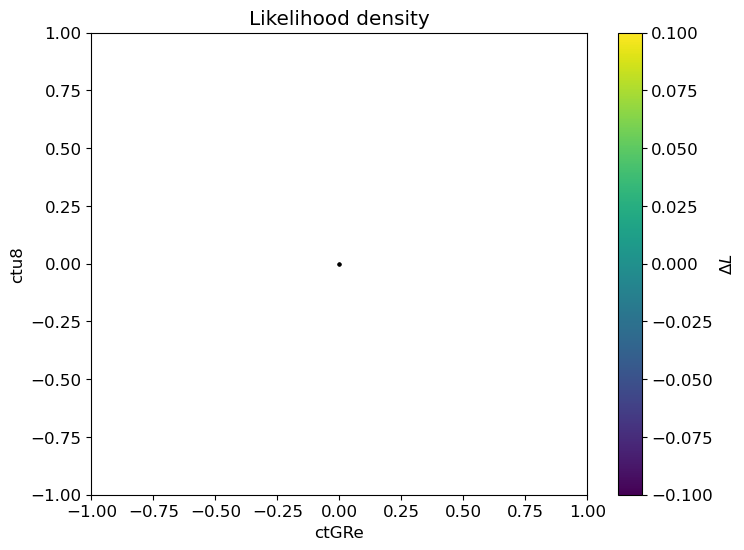

In [656]:
delta_L = -2 * np.log(liklihood / (liklihood_max))
print(delta_L.T)
sm = [0,0]

plt.figure(figsize=(8,6))
plt.rcParams.update({'font.size': 12})

plt.contour(c1_val,c2_val,delta_L.T, levels = [2.30,5.99])
plt.scatter(sm,sm,color = 'black', s = 4)
plt.xlabel("ctGRe")
plt.ylabel("ctu8")
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title("Confidence Intervals: 68%, 95%")
#plt.show()

#plt.figure()
plt.pcolormesh( c1_val, c2_val, delta_L.T,)
plt.xlabel("ctGRe")
plt.ylabel("ctu8")
plt.title("Likelihood density")
plt.colorbar(label="$\Delta L$")
plt.show()